In [3]:
# Cell 1/?: Mount Drive and copy params to Drive project metadata

import os
import shutil
from pathlib import Path
from google.colab import drive
import pprint

# Mount Drive (will prompt for auth)
drive.mount('/content/drive', force_remount=False)

# Preferred project folder name on your Drive
PREFERRED_PROJECT_NAME = "project_visual_search"

# Common Drive locations to check
drive_candidates = [
    Path("/content/drive/MyDrive") / PREFERRED_PROJECT_NAME,
    Path("/content/drive/My Drive") / PREFERRED_PROJECT_NAME  # alternate spacing
]

project_root_drive = None
for p in drive_candidates:
    if p.exists():
        project_root_drive = p.resolve()
        break

if project_root_drive is None:
    print("⚠️ Could not find", PREFERRED_PROJECT_NAME, "on your Drive under MyDrive.")
    print("Please confirm the folder name or upload/move the project folder to your Drive.")
    # Show top-level Drive folders to help locate it
    my_drive = Path("/content/drive/MyDrive")
    print("\nTop-level folders in /content/drive/MyDrive (first 50):")
    for i, f in enumerate(sorted(my_drive.iterdir())):
        if i >= 50:
            break
        print(" -", f.name)
else:
    print("✅ Drive project root detected at:", project_root_drive)
    # Ensure metadata folder on Drive
    metadata_drive = project_root_drive / "metadata"
    metadata_drive.mkdir(parents=True, exist_ok=True)
    print("✅ Ensured Drive metadata dir:", metadata_drive)

    # Path of local params we created earlier
    local_params = Path("/content/metadata/feature_extraction_params.json")
    if local_params.exists():
        dest_params = metadata_drive / local_params.name
        try:
            shutil.copy2(local_params, dest_params)
            print(f"✅ Copied local params -> {dest_params}")
        except Exception as e:
            print("❌ Failed to copy params file:", e)
    else:
        print("⚠️ Local params file not found at:", local_params)
        print("If you created it in a different location, please tell me where it is.")

    # List top-level files in project root (helpful


Mounted at /content/drive
✅ Drive project root detected at: /content/drive/MyDrive/project_visual_search
✅ Ensured Drive metadata dir: /content/drive/MyDrive/project_visual_search/metadata
⚠️ Local params file not found at: /content/metadata/feature_extraction_params.json
If you created it in a different location, please tell me where it is.


In [5]:
!pip install -q rasterio pyarrow torch torchvision tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 109.9 MB/s eta 0:00:00


In [4]:
# Cell 2.2: Recursive search for parquet/csv manifest files in Drive project (and fallback to whole MyDrive)
# Functionality: find any .parquet/.parq/.csv files under the project folder; preview top candidates.
# Use this to locate tiles_manifest_full_fixed.parquet produced in Stage 2.

from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq
import os

PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
MYDRIVE_ROOT = Path("/content/drive/MyDrive")

def find_data_files(root: Path, patterns=(".parquet", ".parq", ".csv")):
    results = []
    if not root.exists():
        return results
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in patterns:
            results.append(p)
    return sorted(results, key=lambda p: p.stat().st_size, reverse=True)

print("Searching project folder:", PROJECT_ROOT)
candidates = find_data_files(PROJECT_ROOT)

if not candidates:
    print("No parquet/csv files found under project folder. Falling back to searching entire MyDrive (this may take a little longer).")
    candidates = find_data_files(MYDRIVE_ROOT)

if not candidates:
    print("⚠️ No parquet/csv files found in MyDrive. If your manifest is on a different Drive account or was not uploaded, please upload or provide the path.")
else:
    print(f"Found {len(candidates)} candidate files. Showing top 20 by size (path — size MB):\n")
    for i, p in enumerate(candidates[:20]):
        try:
            size_mb = round(p.stat().st_size / (1024*1024), 3)
        except Exception:
            size_mb = None
        print(f"[{i}] {p}  ({size_mb} MB)")
    # Preview up to 5 largest candidates
    preview_count = min(5, len(candidates))
    for i in range(preview_count):
        p = candidates[i]
        print("\n" + "="*80)
        print(f"Preview [{i}] -> {p} (size: {round(p.stat().st_size/(1024*1024),3)} MB)")
        try:
            if p.suffix.lower() == ".csv":
                df = pd.read_csv(p, nrows=5)
            else:
                # use pyarrow engine for parquet
                df = pd.read_parquet(p, engine='pyarrow', columns=None).head(5)
            print("Columns:", list(df.columns))
            print("First rows:")
            display(df)
        except Exception as e:
            print("Could not preview file due to error:", e)
            try:
                pqfile = pq.ParquetFile(str(p))
                print("Parquet schema (from pyarrow):")
                print(pqfile.schema)
            except Exception as e2:
                print("Also failed to read schema:", e2)


Searching project folder: /content/drive/MyDrive/project_visual_search
Found 32 candidate files. Showing top 20 by size (path — size MB):

[0] /content/drive/MyDrive/project_visual_search/test/tiles_manifest_full_fixed.parquet  (0.878 MB)
[1] /content/drive/MyDrive/project_visual_search/visual_search_clean/metadata/tiles_manifest_full_fixed.parquet  (0.878 MB)
[2] /content/drive/MyDrive/project_visual_search/test/tiles_manifest_full.parquet  (0.861 MB)
[3] /content/drive/MyDrive/project_visual_search/data/raw_image_first_manifest_enhanced.csv  (0.138 MB)
[4] /content/drive/MyDrive/project_visual_search/visual_search_clean/metadata/raw_image_first_manifest_enhanced.csv  (0.138 MB)
[5] /content/drive/MyDrive/project_visual_search/data/raw_image_first_manifest.csv  (0.095 MB)
[6] /content/drive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0008.parquet  (0.085 MB)
[7] /content/drive/MyDrive/project_visual_search/test/tiles_manifest_parts/tiles_part_0017.parquet  (0.08

,tile_id,parent_image,tile_path_tif,tile_path_thumb,x_off,y_off,tile_w,tile_h,pct_nodata,pct_zero,mean_per_band,std_per_band,norm_p2,norm_p98,bands,dtype,crs,transform
0,GC01PS03D0001_x000000_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,0,0,512,512,4.431534,4.431534,"[109.39849853515625, 163.29808044433594, 163.8...","[46.12362028912823, 43.26876194756978, 43.3857...","[0.0, 0.0, 0.0, 0.0]","[1501.0, 1283.0, 900.0, 4767.0]",4,uint8,None,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
1,GC01PS03D0001_x000384_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,384,0,512,512,1.551437,2.034283,"[72.78559875488281, 97.88042068481445, 90.4600...","[59.7050914399204, 55.12007463547061, 59.96113...","[427.0, 640.0, 450.0, 1838.0]","[1538.0, 1294.0, 921.0, 4569.0]",4,uint8,None,"[1.0, 0.0, 384.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
2,GC01PS03D0001_x000768_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,768,0,512,512,2.472687,2.472687,"[124.25243759155273, 171.2088279724121, 161.85...","[46.62276880657482, 38.58820727028823, 40.2868...","[0.0, 0.0, 0.0, 0.0]","[1446.0, 1268.0, 908.0, 4534.0]",4,uint8,None,"[1.0, 0.0, 768.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
3,GC01PS03D0001_x001152_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,1152,0,512,512,3.380203,3.380203,"[120.50287628173828, 166.79140853881836, 158.5...","[54.15832007821861, 44.688843223191405, 46.599...","[0.0, 0.0, 0.0, 0.0]","[1548.0, 1297.0, 892.0, 4733.0]",4,uint8,None,"[1.0, 0.0, 1152.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
4,GC01PS03D0001_x001536_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,1536,0,501,512,4.884372,4.884372,"[113.45413859780439, 166.3414733033932, 151.02...","[45.14558779609965, 44.98620003138195, 44.1094...","[0.0, 0.0, 0.0, 0.0]","[1288.0, 1165.0, 806.0, 4943.0]",4,uint8,None,"[1.0, 0.0, 1536.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"



Preview [1] -> /content/drive/MyDrive/project_visual_search/visual_search_clean/metadata/tiles_manifest_full_fixed.parquet (size: 0.878 MB)
Columns: ['tile_id', 'parent_image', 'tile_path_tif', 'tile_path_thumb', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'pct_zero', 'mean_per_band', 'std_per_band', 'norm_p2', 'norm_p98', 'bands', 'dtype', 'crs', 'transform']
First rows:


,tile_id,parent_image,tile_path_tif,tile_path_thumb,x_off,y_off,tile_w,tile_h,pct_nodata,pct_zero,mean_per_band,std_per_band,norm_p2,norm_p98,bands,dtype,crs,transform
0,GC01PS03D0001_x000000_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,0,0,512,512,4.431534,4.431534,"[109.39849853515625, 163.29808044433594, 163.8...","[46.12362028912823, 43.26876194756978, 43.3857...","[0.0, 0.0, 0.0, 0.0]","[1501.0, 1283.0, 900.0, 4767.0]",4,uint8,None,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
1,GC01PS03D0001_x000384_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,384,0,512,512,1.551437,2.034283,"[72.78559875488281, 97.88042068481445, 90.4600...","[59.7050914399204, 55.12007463547061, 59.96113...","[427.0, 640.0, 450.0, 1838.0]","[1538.0, 1294.0, 921.0, 4569.0]",4,uint8,None,"[1.0, 0.0, 384.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
2,GC01PS03D0001_x000768_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,768,0,512,512,2.472687,2.472687,"[124.25243759155273, 171.2088279724121, 161.85...","[46.62276880657482, 38.58820727028823, 40.2868...","[0.0, 0.0, 0.0, 0.0]","[1446.0, 1268.0, 908.0, 4534.0]",4,uint8,None,"[1.0, 0.0, 768.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
3,GC01PS03D0001_x001152_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,1152,0,512,512,3.380203,3.380203,"[120.50287628173828, 166.79140853881836, 158.5...","[54.15832007821861, 44.688843223191405, 46.599...","[0.0, 0.0, 0.0, 0.0]","[1548.0, 1297.0, 892.0, 4733.0]",4,uint8,None,"[1.0, 0.0, 1152.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
4,GC01PS03D0001_x001536_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,1536,0,501,512,4.884372,4.884372,"[113.45413859780439, 166.3414733033932, 151.02...","[45.14558779609965, 44.98620003138195, 44.1094...","[0.0, 0.0, 0.0, 0.0]","[1288.0, 1165.0, 806.0, 4943.0]",4,uint8,None,"[1.0, 0.0, 1536.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"



Preview [2] -> /content/drive/MyDrive/project_visual_search/test/tiles_manifest_full.parquet (size: 0.861 MB)
Columns: ['tile_id', 'parent_image', 'tile_path_tif', 'tile_path_thumb', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'pct_zero', 'mean_per_band', 'std_per_band', 'norm_p2', 'norm_p98', 'bands', 'dtype', 'crs', 'transform']
First rows:


,tile_id,parent_image,tile_path_tif,tile_path_thumb,x_off,y_off,tile_w,tile_h,pct_nodata,pct_zero,mean_per_band,std_per_band,norm_p2,norm_p98,bands,dtype,crs,transform
0,GC01PS03D0001_x000000_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,test/thumbnails_batched/GC01PS03D0001_x000000_...,0,0,512,512,4.431534,4.431534,"[109.39849853515625, 163.29808044433594, 163.8...","[46.12362028912823, 43.26876194756978, 43.3857...","[0.0, 0.0, 0.0, 0.0]","[1501.0, 1283.0, 900.0, 4767.0]",4,uint8,None,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
1,GC01PS03D0001_x000384_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,test/thumbnails_batched/GC01PS03D0001_x000384_...,384,0,512,512,1.551437,2.034283,"[72.78559875488281, 97.88042068481445, 90.4600...","[59.7050914399204, 55.12007463547061, 59.96113...","[427.0, 640.0, 450.0, 1838.0]","[1538.0, 1294.0, 921.0, 4569.0]",4,uint8,None,"[1.0, 0.0, 384.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
2,GC01PS03D0001_x000768_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,test/thumbnails_batched/GC01PS03D0001_x000768_...,768,0,512,512,2.472687,2.472687,"[124.25243759155273, 171.2088279724121, 161.85...","[46.62276880657482, 38.58820727028823, 40.2868...","[0.0, 0.0, 0.0, 0.0]","[1446.0, 1268.0, 908.0, 4534.0]",4,uint8,None,"[1.0, 0.0, 768.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
3,GC01PS03D0001_x001152_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,test/thumbnails_batched/GC01PS03D0001_x001152_...,1152,0,512,512,3.380203,3.380203,"[120.50287628173828, 166.79140853881836, 158.5...","[54.15832007821861, 44.688843223191405, 46.599...","[0.0, 0.0, 0.0, 0.0]","[1548.0, 1297.0, 892.0, 4733.0]",4,uint8,None,"[1.0, 0.0, 1152.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
4,GC01PS03D0001_x001536_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,test/thumbnails_batched/GC01PS03D0001_x001536_...,1536,0,501,512,4.884372,4.884372,"[113.45413859780439, 166.3414733033932, 151.02...","[45.14558779609965, 44.98620003138195, 44.1094...","[0.0, 0.0, 0.0, 0.0]","[1288.0, 1165.0, 806.0, 4943.0]",4,uint8,None,"[1.0, 0.0, 1536.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"



Preview [3] -> /content/drive/MyDrive/project_visual_search/data/raw_image_first_manifest_enhanced.csv (size: 0.138 MB)
Columns: ['filename', 'set', 'width', 'height', 'bands', 'crs', 'dtype', 'nodata', 'percent_nodata', 'sample_min', 'sample_max', 'sample_mean', 'thumb', 'status', 'filesize_mb', 'has_pair', 'sample_std', 'percent_zero', 'cloud_score']
First rows:


,filename,set,width,height,bands,crs,dtype,nodata,percent_nodata,sample_min,sample_max,sample_mean,thumb,status,filesize_mb,has_pair,sample_std,percent_zero,cloud_score
0,development-set/GC01PS03D0001.jpg,development-set,2037,1401,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,184.03982543945312;152.7432861328125;157.31864...,data/thumbs/development-set_GC01PS03D0001.jpg.jpg,ok,1.722,True,56.5260009765625;51.362998962402344;55.0709991...,1.454;1.393;1.246;1.381,5.115
1,development-set/GC01PS03D0001.tif,development-set,2037,1401,4,NaN,uint16,0.0,1.957,0.0;0.0;0.0;0.0,3129.0;2537.0;1691.0;5446.0,668.9884033203125;831.8329467773438;562.778869...,data/thumbs/development-set_GC01PS03D0001.tif.jpg,ok,21.781,True,250.25999450683594;172.1790008544922;134.05599...,1.677;1.677;1.677;1.677,3.118
2,development-set/GC01PS03D0002.jpg,development-set,2037,1401,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,92.12244415283203;99.32591247558594;92.2324218...,data/thumbs/development-set_GC01PS03D0002.jpg.jpg,ok,1.910,True,64.00800323486328;64.53800201416016;61.8899993...,1.348;1.352;1.329;1.222,3.505
3,development-set/GC01PS03D0002.tif,development-set,2037,1401,4,NaN,uint16,0.0,1.957,0.0;0.0;0.0;0.0,3301.0;2502.0;1805.0;4868.0,2309.35302734375;1891.7686767578125;1248.69140...,data/thumbs/development-set_GC01PS03D0002.tif.jpg,ok,21.781,True,464.5190124511719;342.1610107421875;231.852005...,1.677;1.677;1.677;1.677,11.186
4,development-set/GC01PS03D0007.jpg,development-set,1960,1583,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,191.25804138183594;167.2568817138672;184.62640...,data/thumbs/development-set_GC01PS03D0007.jpg.jpg,ok,1.795,True,58.25899887084961;52.00400161743164;55.7830009...,1.415;1.377;1.299;1.403,13.363



Preview [4] -> /content/drive/MyDrive/project_visual_search/visual_search_clean/metadata/raw_image_first_manifest_enhanced.csv (size: 0.138 MB)
Columns: ['filename', 'set', 'width', 'height', 'bands', 'crs', 'dtype', 'nodata', 'percent_nodata', 'sample_min', 'sample_max', 'sample_mean', 'thumb', 'status', 'filesize_mb', 'has_pair', 'sample_std', 'percent_zero', 'cloud_score']
First rows:


,filename,set,width,height,bands,crs,dtype,nodata,percent_nodata,sample_min,sample_max,sample_mean,thumb,status,filesize_mb,has_pair,sample_std,percent_zero,cloud_score
0,development-set/GC01PS03D0001.jpg,development-set,2037,1401,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,184.03982543945312;152.7432861328125;157.31864...,data/thumbs/development-set_GC01PS03D0001.jpg.jpg,ok,1.722,True,56.5260009765625;51.362998962402344;55.0709991...,1.454;1.393;1.246;1.381,5.115
1,development-set/GC01PS03D0001.tif,development-set,2037,1401,4,NaN,uint16,0.0,1.957,0.0;0.0;0.0;0.0,3129.0;2537.0;1691.0;5446.0,668.9884033203125;831.8329467773438;562.778869...,data/thumbs/development-set_GC01PS03D0001.tif.jpg,ok,21.781,True,250.25999450683594;172.1790008544922;134.05599...,1.677;1.677;1.677;1.677,3.118
2,development-set/GC01PS03D0002.jpg,development-set,2037,1401,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,92.12244415283203;99.32591247558594;92.2324218...,data/thumbs/development-set_GC01PS03D0002.jpg.jpg,ok,1.910,True,64.00800323486328;64.53800201416016;61.8899993...,1.348;1.352;1.329;1.222,3.505
3,development-set/GC01PS03D0002.tif,development-set,2037,1401,4,NaN,uint16,0.0,1.957,0.0;0.0;0.0;0.0,3301.0;2502.0;1805.0;4868.0,2309.35302734375;1891.7686767578125;1248.69140...,data/thumbs/development-set_GC01PS03D0002.tif.jpg,ok,21.781,True,464.5190124511719;342.1610107421875;231.852005...,1.677;1.677;1.677;1.677,11.186
4,development-set/GC01PS03D0007.jpg,development-set,1960,1583,4,NaN,float32,NaN,0.000,0.0;0.0;0.0;0.0,255.0;255.0;255.0;255.0,191.25804138183594;167.2568817138672;184.62640...,data/thumbs/development-set_GC01PS03D0007.jpg.jpg,ok,1.795,True,58.25899887084961;52.00400161743164;55.7830009...,1.415;1.377;1.299;1.403,13.363


In [5]:
# Cell 2.2: Confirm manifest path, inspect key columns, and check tile TIFF existence for first rows
# Functionality: load the found manifest, show key columns, resolve tile_path_tif relative to project root,
# and check whether the referenced tile files exist on Drive. This helps us adapt the TileDataset.

from pathlib import Path
import pandas as pd
import json

# ---- Edit only if your manifest path differs ----
manifest_path = Path("/content/drive/MyDrive/project_visual_search/test/tiles_manifest_full_fixed.parquet")
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
# -------------------------------------------------

print("Using manifest:", manifest_path)
print("Exists?:", manifest_path.exists())
if not manifest_path.exists():
    raise FileNotFoundError(f"Manifest not found at: {manifest_path}. Please check the path.")

# Load small preview
df = pd.read_parquet(manifest_path, engine='pyarrow')
print("Manifest rows:", len(df))
print("Columns:", list(df.columns))

# show first 5 rows of key columns
preview_cols = ['tile_id', 'parent_image', 'tile_path_tif', 'tile_path_thumb', 'mean_per_band', 'std_per_band', 'norm_p2', 'norm_p98', 'bands']
preview_cols = [c for c in preview_cols if c in df.columns]
print("\nPreview (first 5 rows) of key columns:")
display(df[preview_cols].head(5))

# Resolve tile_path_tif values to absolute paths and check file existence for first 10 rows
print("\nResolving tile paths and checking existence (first 10 rows):")
for i, row in df.head(10).iterrows():
    raw_path = row['tile_path_tif']
    # raw_path may be absolute (starts with /) or relative; attempt resolution
    p = Path(raw_path)
    resolved = p
    if not p.exists():
        # try relative to project root
        candidate = PROJECT_ROOT / raw_path
        if candidate.exists():
            resolved = candidate
        else:
            # try prefixing '/content/drive/MyDrive/project_visual_search/' if not already
            candidate2 = Path("/content/drive/MyDrive/project_visual_search") / raw_path
            if candidate2.exists():
                resolved = candidate2
    exists_flag = resolved.exists()
    print(f"[{i}] raw: {raw_path}  -> resolved: {resolved}   exists: {exists_flag}")
    # If exists and is file, print size
    if exists_flag and resolved.is_file():
        print("     size (MB):", round(resolved.stat().st_size / (1024*1024), 3))


Using manifest: /content/drive/MyDrive/project_visual_search/test/tiles_manifest_full_fixed.parquet
Exists?: True
Manifest rows: 12058
Columns: ['tile_id', 'parent_image', 'tile_path_tif', 'tile_path_thumb', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'pct_zero', 'mean_per_band', 'std_per_band', 'norm_p2', 'norm_p98', 'bands', 'dtype', 'crs', 'transform']

Preview (first 5 rows) of key columns:


,tile_id,parent_image,tile_path_tif,tile_path_thumb,mean_per_band,std_per_band,norm_p2,norm_p98,bands
0,GC01PS03D0001_x000000_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,"[109.39849853515625, 163.29808044433594, 163.8...","[46.12362028912823, 43.26876194756978, 43.3857...","[0.0, 0.0, 0.0, 0.0]","[1501.0, 1283.0, 900.0, 4767.0]",4
1,GC01PS03D0001_x000384_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,"[72.78559875488281, 97.88042068481445, 90.4600...","[59.7050914399204, 55.12007463547061, 59.96113...","[427.0, 640.0, 450.0, 1838.0]","[1538.0, 1294.0, 921.0, 4569.0]",4
2,GC01PS03D0001_x000768_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,"[124.25243759155273, 171.2088279724121, 161.85...","[46.62276880657482, 38.58820727028823, 40.2868...","[0.0, 0.0, 0.0, 0.0]","[1446.0, 1268.0, 908.0, 4534.0]",4
3,GC01PS03D0001_x001152_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,"[120.50287628173828, 166.79140853881836, 158.5...","[54.15832007821861, 44.688843223191405, 46.599...","[0.0, 0.0, 0.0, 0.0]","[1548.0, 1297.0, 892.0, 4733.0]",4
4,GC01PS03D0001_x001536_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,"[113.45413859780439, 166.3414733033932, 151.02...","[45.14558779609965, 44.98620003138195, 44.1094...","[0.0, 0.0, 0.0, 0.0]","[1288.0, 1165.0, 806.0, 4943.0]",4



Resolving tile paths and checking existence (first 10 rows):
[0] raw: data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000000.tif  -> resolved: /content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000000.tif   exists: True
     size (MB): 0.577
[1] raw: data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000384_y000000.tif  -> resolved: /content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000384_y000000.tif   exists: True
     size (MB): 0.684
[2] raw: data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000768_y000000.tif  -> resolved: /content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000768_y000000.tif   exists: True
     size (MB): 0.613
[3] raw: data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x001152_y000000.tif  -> resolved: /content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x001152_y000000.tif   e

In [6]:
# Cell 2.4: Stage3 setup + TileDataset (manifest-tied) + smoke-test
# Functionality:
#  - Create project stage3 directory and features_shards subdir on Drive
#  - Implement TileDataset wired to the exact manifest found earlier
#  - Use per-tile norm_p2 / norm_p98 for scaling
#  - Skip tiles with pct_nodata > 90%
#  - Include tile_path_thumb and extra metadata columns (cloud_score, tile_w, tile_h, x_off, y_off)
#  - Run a smoke-test over debug_limit tiles (200) and print diagnostics:
#      * how many tiles loaded / skipped
#      * sample shapes/statistics for rgb_tensor and ms_tensor
#      * create a small DataLoader batch and print its shapes
#
# NOTE: This cell does NOT write embeddings or large outputs yet. It prepares and validates the dataset and folders.

import os
import json
from pathlib import Path
import math
import numpy as np
import pandas as pd
import rasterio
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

# ----------------- Config (hard-coded to your choices) -----------------
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
MANIFEST_PATH = PROJECT_ROOT / "test" / "tiles_manifest_full_fixed.parquet"   # the manifest we found
STAGE3_DIR = PROJECT_ROOT / "stage3"
SHARDS_DIR = STAGE3_DIR / "features_shards"
DEBUG_LIMIT = 200   # as you requested
PCT_NODATA_THRESHOLD = 90.0  # skip if pct_nodata > 90
MODEL_INPUT_SIZE = 224

# create stage3 & shards dir
STAGE3_DIR.mkdir(parents=True, exist_ok=True)
SHARDS_DIR.mkdir(parents=True, exist_ok=True)
print("✅ stage3 dir ensured at:", STAGE3_DIR)
print("✅ shards dir ensured at:", SHARDS_DIR)

# load manifest
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Expected manifest not found at: {MANIFEST_PATH}")
df = pd.read_parquet(MANIFEST_PATH, engine='pyarrow')
print("Loaded manifest rows:", len(df))
print("Sample manifest columns:", list(df.columns)[:60])

# Reduce to debug subset and apply pct_nodata filter
df_debug = df.head(DEBUG_LIMIT).copy().reset_index(drop=True)

# Ensure columns exist and coerce numeric types where needed
for col in ['pct_nodata', 'tile_w', 'tile_h', 'x_off', 'y_off', 'cloud_score']:
    if col in df_debug.columns:
        # coerce to numeric with NaN fallback
        df_debug[col] = pd.to_numeric(df_debug[col], errors='coerce')
    else:
        # create column with NaN if missing so code downstream can still reference it
        df_debug[col] = np.nan

initial_count = len(df_debug)
df_debug_filtered = df_debug[df_debug['pct_nodata'] <= PCT_NODATA_THRESHOLD].reset_index(drop=True)
skipped_count = initial_count - len(df_debug_filtered)
print(f"Tiles in debug subset: {initial_count}; skipped due to pct_nodata>{PCT_NODATA_THRESHOLD}: {skipped_count}; to process: {len(df_debug_filtered)}")

# helper functions (subset of what we used earlier)
def try_parse_list_field(x):
    import ast, json
    if x is None:
        return None
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    if isinstance(x, str):
        try:
            val = json.loads(x)
            if isinstance(val, (list, tuple)):
                return list(val)
        except Exception:
            pass
        try:
            val = ast.literal_eval(x)
            if isinstance(val, (list, tuple)):
                return list(val)
        except Exception:
            pass
    return None

def rescale_band_with_p2p98(band: np.ndarray, p2, p98):
    if p2 is None or p98 is None or (isinstance(p2, (float,int)) and isinstance(p98,(float,int)) and math.isclose(float(p2), float(p98))):
        mn, mx = float(np.nanmin(band)), float(np.nanmax(band))
        if math.isclose(mn, mx):
            return np.clip(band, 0, 255).astype(np.float32) / 255.0
        return np.clip((band - mn) / (mx - mn), 0.0, 1.0).astype(np.float32)
    clipped = np.clip(band, float(p2), float(p98))
    return ((clipped - float(p2)) / (float(p98) - float(p2))).astype(np.float32)

def read_tif_bands(path: Path):
    with rasterio.Env():
        with rasterio.open(str(path)) as src:
            arr = src.read()  # (bands, H, W)
    return arr.astype(np.float32), arr.shape[0]

def pil_resize_from_numpy(img_np: np.ndarray, size: int, resample=Image.BILINEAR):
    c, h, w = img_np.shape
    img_hwc = np.transpose(img_np, (1,2,0))
    if img_hwc.dtype.kind == 'f':
        img_u8 = (np.clip(img_hwc,0.0,1.0)*255.0).round().astype(np.uint8)
        pil = Image.fromarray(img_u8)
        pil = pil.resize((size,size), resample=resample)
        out = np.asarray(pil).astype(np.float32)/255.0
    else:
        pil = Image.fromarray(img_hwc)
        pil = pil.resize((size,size), resample=resample)
        out = np.asarray(pil).astype(np.float32)/255.0
    out_chw = np.transpose(out, (2,0,1))
    return out_chw

# ----------------- Minimal Dataset tied to the debug DataFrame -----------------
class TileDatasetDebug(Dataset):
    def __init__(self, df_manifest: pd.DataFrame, project_root: Path, input_size:int=MODEL_INPUT_SIZE):
        self.df = df_manifest.reset_index(drop=True)
        self.project_root = project_root
        self.input_size = input_size
        required_cols = ['tile_path_tif', 'norm_p2', 'norm_p98', 'pct_nodata', 'tile_path_thumb']
        missing = [c for c in required_cols if c not in self.df.columns]
        if missing:
            raise KeyError(f"Expected columns missing in manifest: {missing}. Found columns: {list(self.df.columns)}")
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        raw_path = row['tile_path_tif']
        p = Path(raw_path)
        resolved = p if p.exists() else (self.project_root / raw_path)
        if not resolved.exists():
            # fallback: sometimes stored with an extra prefix
            alt = Path("/content/drive/MyDrive/project_visual_search") / raw_path
            if alt.exists():
                resolved = alt
        if not resolved.exists():
            raise FileNotFoundError(f"Tile file not found for row {idx}: tried {resolved} and {p}")
        # read bands
        arr, nbands = read_tif_bands(resolved)
        # get p2/p98 lists
        p2_list = try_parse_list_field(row.get('norm_p2'))
        p98_list = try_parse_list_field(row.get('norm_p98'))
        # apply per-band scaling
        bands_scaled = []
        for b in range(arr.shape[0]):
            band = arr[b,:,:]
            if p2_list and p98_list and b < len(p2_list):
                band_scaled = rescale_band_with_p2p98(band, p2_list[b], p98_list[b])
            else:
                band_scaled = np.clip(band/255.0, 0.0, 1.0).astype(np.float32)
            bands_scaled.append(band_scaled)
        img_scaled = np.stack(bands_scaled, axis=0)  # (C,H,W) float32 0..1
        img_resized = pil_resize_from_numpy(img_scaled, self.input_size)
        # rgb tensor
        if img_resized.shape[0] >= 3:
            rgb = img_resized[:3,:,:]
        else:
            rgb = np.repeat(img_resized[0:1,:,:], 3, axis=0)
        # apply ImageNet norm
        IMAGENET_MEAN = [0.485,0.456,0.406]
        IMAGENET_STD = [0.229,0.224,0.225]
        rgb_tensor = torch.from_numpy(rgb).float()
        for c in range(3):
            rgb_tensor[c] = (rgb_tensor[c] - IMAGENET_MEAN[c]) / IMAGENET_STD[c]
        # ms tensor ensure 4 channels
        if img_resized.shape[0] >= 4:
            ms = img_resized[:4,:,:]
        else:
            pad = np.zeros((4 - img_resized.shape[0], self.input_size, self.input_size), dtype=np.float32)
            ms = np.concatenate([img_resized, pad], axis=0)
        ms_tensor = torch.from_numpy(ms).float()

        item = {
            "tile_idx": int(idx),
            "tile_id": row.get('tile_id'),
            "parent_image": row.get('parent_image'),
            "tile_path_tif": str(resolved),
            "tile_path_thumb": row.get('tile_path_thumb'),
            "pct_nodata": float(row.get('pct_nodata')) if pd.notna(row.get('pct_nodata')) else None,
            "pct_zero": float(row.get('pct_zero')) if 'pct_zero' in row and pd.notna(row.get('pct_zero')) else None,
            "mean_per_band": try_parse_list_field(row.get('mean_per_band')),
            "std_per_band": try_parse_list_field(row.get('std_per_band')),
            "norm_p2": try_parse_list_field(row.get('norm_p2')),
            "norm_p98": try_parse_list_field(row.get('norm_p98')),
            "bands": int(row.get('bands')) if pd.notna(row.get('bands')) else None,
            "dtype": row.get('dtype') if 'dtype' in row else None,
            "cloud_score": float(row.get('cloud_score')) if pd.notna(row.get('cloud_score')) else None,
            "tile_w": int(row.get('tile_w')) if pd.notna(row.get('tile_w')) else None,
            "tile_h": int(row.get('tile_h')) if pd.notna(row.get('tile_h')) else None,
            "x_off": int(row.get('x_off')) if pd.notna(row.get('x_off')) else None,
            "y_off": int(row.get('y_off')) if pd.notna(row.get('y_off')) else None,
            "rgb_tensor": rgb_tensor,
            "ms_tensor": ms_tensor
        }
        return item

# instantiate dataset and dataloader for debug subset
ds_debug = TileDatasetDebug(df_debug_filtered, PROJECT_ROOT, input_size=MODEL_INPUT_SIZE)
print("Dataset length (debug subset after nodata filter):", len(ds_debug))

# Show up to first 5 items
for i in range(min(5, len(ds_debug))):
    it = ds_debug[i]
    print(f"\n--- item {i} ---")
    print("tile_idx:", it['tile_idx'])
    print("tile_id:", it['tile_id'])
    print("tile_path_tif:", it['tile_path_tif'])
    print("tile_path_thumb:", it['tile_path_thumb'])
    print("pct_nodata:", it['pct_nodata'])
    print("pct_zero:", it['pct_zero'])
    print("mean_per_band:", it['mean_per_band'])
    print("std_per_band:", it['std_per_band'])
    print("norm_p2:", it['norm_p2'])
    print("norm_p98:", it['norm_p98'])
    print("bands:", it['bands'], "dtype:", it['dtype'])
    print("cloud_score:", it['cloud_score'])
    print("tile_w, tile_h:", it['tile_w'], it['tile_h'])
    print("x_off, y_off:", it['x_off'], it['y_off'])
    print("rgb_tensor shape:", tuple(it['rgb_tensor'].shape), "min/max:", float(it['rgb_tensor'].min()), float(it['rgb_tensor'].max()))
    print("ms_tensor shape:", tuple(it['ms_tensor'].shape), "min/max:", float(it['ms_tensor'].min()), float(it['ms_tensor'].max()))

# quick DataLoader batch test
def collate_debug(batch):
    return {
        "tile_idxs": [it['tile_idx'] for it in batch],
        "rgb": torch.stack([it['rgb_tensor'] for it in batch]),
        "ms": torch.stack([it['ms_tensor'] for it in batch]),
        "meta": [{k:v for k,v in it.items() if not isinstance(v, torch.Tensor)} for it in batch]
    }

dl = DataLoader(ds_debug, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_debug)
batch = next(iter(dl))
print("\nExample batch shapes:")
print("tile count in batch:", len(batch['tile_idxs']))
print("rgb batch shape:", batch['rgb'].shape)
print("ms batch shape:", batch['ms'].shape)
print("Example meta keys in batch[0]:", list(batch['meta'][0].keys()))

print("\n✅ Smoke-test complete. Dataset is ready for feature extraction (inference).")
print("Stage3 directory:", STAGE3_DIR)
print("Shard directory:", SHARDS_DIR)


✅ stage3 dir ensured at: /content/drive/MyDrive/project_visual_search/stage3
✅ shards dir ensured at: /content/drive/MyDrive/project_visual_search/stage3/features_shards
Loaded manifest rows: 12058
Sample manifest columns: ['tile_id', 'parent_image', 'tile_path_tif', 'tile_path_thumb', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'pct_zero', 'mean_per_band', 'std_per_band', 'norm_p2', 'norm_p98', 'bands', 'dtype', 'crs', 'transform']
Tiles in debug subset: 200; skipped due to pct_nodata>90.0: 0; to process: 200
Dataset length (debug subset after nodata filter): 200

--- item 0 ---
tile_idx: 0
tile_id: GC01PS03D0001_x000000_y000000
tile_path_tif: /content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000000.tif
tile_path_thumb: /gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000000_y000000.jpg
pct_nodata: 4.4315338134765625
pct_zero: 4.4315338134765625
mean_per_band: [np.float64(109.39849853515625), np.f

In [8]:
# Cell 2.5: PCA n_components safe-fit for debug subset + optional zero-padding to 512
# Replace the failed PCA fitting step with this safe version.
# Assumes rgb_pooled (N,2048), ms_pooled (N,2048), meta_rows list exist in memory from previous step.

import pickle
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
import pandas as pd

# Config (must match previous cell)
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3_DIR = PROJECT_ROOT / "stage3"
SHARDS_DIR = STAGE3_DIR / "features_shards"
POOL_FEAT_DIM = 2048
EMBED_DIM = 512
SHARD_PREFIX = "shard_debug_000"
PCA_RGB_PATH = STAGE3_DIR / f"pca_rgb_{POOL_FEAT_DIM}to{EMBED_DIM}.pkl"
PCA_MS_PATH  = STAGE3_DIR / f"pca_ms_{POOL_FEAT_DIM}to{EMBED_DIM}.pkl"
RGB_NPY = SHARDS_DIR / f"{SHARD_PREFIX}_rgb.npy"
MS_NPY  = SHARDS_DIR / f"{SHARD_PREFIX}_ms.npy"
META_PARQUET = SHARDS_DIR / f"{SHARD_PREFIX}_meta.parquet"

# make sure rgb_pooled and ms_pooled exist
assert 'rgb_pooled' in globals() and 'ms_pooled' in globals(), "rgb_pooled or ms_pooled not found in workspace. Re-run feature extraction batches."

N_rgb = rgb_pooled.shape[0]
N_ms  = ms_pooled.shape[0]
print("Detected pooled shapes — RGB:", rgb_pooled.shape, "MS:", ms_pooled.shape)

# determine safe n_components
n_components_actual_rgb = min(EMBED_DIM, N_rgb, POOL_FEAT_DIM)
n_components_actual_ms  = min(EMBED_DIM, N_ms, POOL_FEAT_DIM)
print("Requested embed dim:", EMBED_DIM)
print("Fitting PCA with n_components_actual (RGB):", n_components_actual_rgb, " (MS):", n_components_actual_ms)

# Fit PCA safely
pca_rgb = PCA(n_components=n_components_actual_rgb, svd_solver='randomized', whiten=False, random_state=42)
pca_rgb.fit(rgb_pooled)
print("  RGB PCA fitted. explained variance ratio sum:", float(pca_rgb.explained_variance_ratio_.sum()))

pca_ms = PCA(n_components=n_components_actual_ms, svd_solver='randomized', whiten=False, random_state=42)
pca_ms.fit(ms_pooled)
print("  MS PCA fitted. explained variance ratio sum:", float(pca_ms.explained_variance_ratio_.sum()))

# Save PCA objects
with open(PCA_RGB_PATH, "wb") as f:
    pickle.dump(pca_rgb, f)
with open(PCA_MS_PATH, "wb") as f:
    pickle.dump(pca_ms, f)
print("Saved PCA objects to:", PCA_RGB_PATH.name, PCA_MS_PATH.name)

# Transform to embeddings
emb_rgb_actual = pca_rgb.transform(rgb_pooled).astype(np.float32)  # shape (N, n_components_actual_rgb)
emb_ms_actual  = pca_ms.transform(ms_pooled).astype(np.float32)

# Pad to EMBED_DIM if needed (debug-only padding)
def pad_to_dim(mat, target_dim):
    n, d = mat.shape
    if d >= target_dim:
        return mat[:, :target_dim]
    pad_width = target_dim - d
    pad = np.zeros((n, pad_width), dtype=np.float32)
    return np.concatenate([mat, pad], axis=1)

emb_rgb_padded = pad_to_dim(emb_rgb_actual, EMBED_DIM)
emb_ms_padded  = pad_to_dim(emb_ms_actual, EMBED_DIM)

# Normalize (L2) using padded embeddings (so final saved files have shape (N, EMBED_DIM))
def l2_normalize_rows(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms==0] = 1.0
    return x / norms

emb_rgb_norm = l2_normalize_rows(emb_rgb_padded).astype(np.float32)
emb_ms_norm  = l2_normalize_rows(emb_ms_padded).astype(np.float32)

# Save .npy shards
np.save(RGB_NPY, emb_rgb_norm)
np.save(MS_NPY, emb_ms_norm)
print("Saved padded .npy shards:", RGB_NPY.name, MS_NPY.name)
print("Shard sizes (MB):", round(RGB_NPY.stat().st_size/(1024*1024),3), round(MS_NPY.stat().st_size/(1024*1024),3))

# Save meta parquet (recreate from meta_rows if needed)
if 'meta_rows' in globals():
    meta_df = pd.DataFrame(meta_rows)
    meta_df['row_in_shard'] = meta_df.index.astype(int)
    cols = ['row_in_shard','tile_idx','tile_id','parent_image','tile_path_tif','tile_path_thumb','x_off','y_off',
            'pct_nodata','pct_zero','cloud_score','mean_per_band','std_per_band','tile_w','tile_h']
    meta_df = meta_df[cols]
    meta_df.to_parquet(META_PARQUET, index=False)
    print("Saved shard meta parquet:", META_PARQUET.name, "rows:", len(meta_df))
else:
    print("Warning: meta_rows not found in workspace; shard meta not saved.")

# Quick nearest-self check — compute using actual (unpadded) embeddings if possible
from sklearn.metrics.pairwise import euclidean_distances
emb_check = emb_rgb_actual  # use actual dimension (not padded) for honest check
dists = euclidean_distances(emb_check, emb_check)
nearest_idx = np.argmin(dists, axis=1)
self_matches = (nearest_idx == np.arange(dists.shape[0])).sum()
print(f"Nearest-self matches on actual PCA dims (RGB): {self_matches} / {dists.shape[0]}")

print("\n✅ PCA fitted safely and debug shards saved (padded to 512 if needed).")
print("Files written to:", SHARDS_DIR)
print("Note: For the debug run we used n_components_actual =", n_components_actual_rgb,
      "for RGB and", n_components_actual_ms, "for MS. These were padded to", EMBED_DIM,
      "for file shape consistency. For the full run we'll fit PCA on the full dataset so true 512-D PCA is produced.")


Detected pooled shapes — RGB: (200, 2048) MS: (200, 2048)
Requested embed dim: 512
Fitting PCA with n_components_actual (RGB): 200  (MS): 200
  RGB PCA fitted. explained variance ratio sum: 1.000000238418579
  MS PCA fitted. explained variance ratio sum: 1.0000004768371582
Saved PCA objects to: pca_rgb_2048to512.pkl pca_ms_2048to512.pkl
Saved padded .npy shards: shard_debug_000_rgb.npy shard_debug_000_ms.npy
Shard sizes (MB): 0.391 0.391
Saved shard meta parquet: shard_debug_000_meta.parquet rows: 200
Nearest-self matches on actual PCA dims (RGB): 193 / 200

✅ PCA fitted safely and debug shards saved (padded to 512 if needed).
Files written to: /content/drive/MyDrive/project_visual_search/stage3/features_shards
Note: For the debug run we used n_components_actual = 200 for RGB and 200 for MS. These were padded to 512 for file shape consistency. For the full run we'll fit PCA on the full dataset so true 512-D PCA is produced.


In [9]:
# Cell 2.6: Inspect debug shard files (RGB + MS) and shard metadata
# Functionality:
#  - Load shard .npy embeddings for RGB and MS and corresponding meta parquet
#  - Print shapes, dtypes, NaN checks, per-dimension mean/std (summary), and top variance dims
#  - Show file sizes and first 8 rows of the shard_meta parquet for quick verification
#  - Small, optimized (uses numpy/pandas); safe to run on Colab

import numpy as np
import pandas as pd
from pathlib import Path
import os

# ---- paths (adjust only if you moved files) ----
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
SHARDS_DIR = PROJECT_ROOT / "stage3" / "features_shards"
SHARD_PREFIX = "shard_debug_000"
RGB_NPY = SHARDS_DIR / f"{SHARD_PREFIX}_rgb.npy"
MS_NPY  = SHARDS_DIR / f"{SHARD_PREFIX}_ms.npy"
META_PARQUET = SHARDS_DIR / f"{SHARD_PREFIX}_meta.parquet"

# ---- quick existence checks ----
for p in [RGB_NPY, MS_NPY, META_PARQUET]:
    if not p.exists():
        raise FileNotFoundError(f"Expected file not found: {p}")

print("Shard files found. Loading...")

# ---- load (memory for debug-size is fine) ----
emb_rgb = np.load(RGB_NPY, mmap_mode=None)   # full load
emb_ms  = np.load(MS_NPY, mmap_mode=None)
meta_df = pd.read_parquet(META_PARQUET)

# ---- basic info ----
def file_size_mb(p: Path):
    return round(p.stat().st_size / (1024*1024), 6)

print("\nFILES:")
print(" - RGB .npy:", RGB_NPY, "| size (MB):", file_size_mb(RGB_NPY))
print(" - MS  .npy:", MS_NPY,  "| size (MB):", file_size_mb(MS_NPY))
print(" - META .parquet:", META_PARQUET, "| size (MB):", file_size_mb(META_PARQUET))

print("\nEMBEDDING ARRAYS:")
print(" - emb_rgb shape:", emb_rgb.shape, "dtype:", emb_rgb.dtype, "min/max:", float(np.nanmin(emb_rgb)), "/", float(np.nanmax(emb_rgb)))
print(" - emb_ms  shape:", emb_ms.shape,  "dtype:", emb_ms.dtype,  "min/max:", float(np.nanmin(emb_ms)), "/", float(np.nanmax(emb_ms)))

# ---- NaN / Inf checks ----
def nan_inf_stats(x):
    n_nan = np.isnan(x).sum()
    n_inf = np.isinf(x).sum()
    return int(n_nan), int(n_inf)

rgb_nan, rgb_inf = nan_inf_stats(emb_rgb)
ms_nan, ms_inf = nan_inf_stats(emb_ms)
print("\nNaN/Inf checks:")
print(" - RGB: n_nan =", rgb_nan, ", n_inf =", rgb_inf)
print(" - MS : n_nan =", ms_nan, ", n_inf =", ms_inf)

# ---- per-dimension summary (mean/std) but we avoid printing all 512 numbers;
# compute global stats and top variance dims
def per_dim_stats(x):
    # x shape: (N, D)
    means = np.mean(x, axis=0)
    stds  = np.std(x, axis=0)
    variances = stds**2
    return means, stds, variances

means_rgb, stds_rgb, var_rgb = per_dim_stats(emb_rgb)
means_ms,  stds_ms,  var_ms  = per_dim_stats(emb_ms)

print("\nEmbedding summary (per-dim):")
print(" - RGB: mean of means =", float(np.mean(means_rgb)), ", mean of stds =", float(np.mean(stds_rgb)))
print(" - MS : mean of means =", float(np.mean(means_ms)),  ", mean of stds =", float(np.mean(stds_ms)))

# top 5 dims with largest variance (helpful to see if some dims are degenerate)
topk = 5
top_dims_rgb = np.argsort(var_rgb)[-topk:][::-1]
top_dims_ms  = np.argsort(var_ms)[-topk:][::-1]
print(f"\nTop {topk} RGB dims by variance (dim index : var, mean, std):")
for d in top_dims_rgb:
    print(f"  dim {d:03d}: var={float(var_rgb[d]):.6f}, mean={float(means_rgb[d]):.6f}, std={float(stds_rgb[d]):.6f}")

print(f"\nTop {topk} MS dims by variance (dim index : var, mean, std):")
for d in top_dims_ms:
    print(f"  dim {d:03d}: var={float(var_ms[d]):.6f}, mean={float(means_ms[d]):.6f}, std={float(stds_ms[d]):.6f}")

# ---- small distribution checks (percentiles of pairwise norms may be expensive; compute per-row norm) ----
row_norms_rgb = np.linalg.norm(emb_rgb, axis=1)
row_norms_ms  = np.linalg.norm(emb_ms, axis=1)
print("\nPer-row L2 norm stats (embeddings):")
for name, norms in [("RGB", row_norms_rgb), ("MS", row_norms_ms)]:
    print(f" - {name}: mean {float(norms.mean()):.4f}, std {float(norms.std()):.4f}, min {float(norms.min()):.4f}, 25p {float(np.percentile(norms,25)):.4f}, 50p {float(np.percentile(norms,50)):.4f}, 75p {float(np.percentile(norms,75)):.4f}, max {float(norms.max()):.4f}")

# ---- Meta preview ----
print("\nShard meta preview (first 8 rows):")
pd.set_option('display.max_colwidth', 140)
display(meta_df.head(8))
pd.reset_option('display.max_colwidth')

# ---- Quick cross-check: rows match ----
N_meta = len(meta_df)
N_rgb, D_rgb = emb_rgb.shape
N_ms,  D_ms  = emb_ms.shape
print(f"\nRows: meta={N_meta}, emb_rgb rows={N_rgb}, emb_ms rows={N_ms}. Dimensions: RGB={D_rgb}, MS={D_ms}")
if N_meta != N_rgb or N_meta != N_ms:
    print("⚠️ Warning: row counts in meta and embeddings differ — this must be investigated before indexing.")
else:
    print("✅ Row counts match between meta and embedding files.")

# ---- Save a tiny summary CSV for quick review (optional) ----
summary = {
    "rgb_n_rows": int(N_rgb), "rgb_dim": int(D_rgb), "rgb_n_nan": int(rgb_nan), "rgb_n_inf": int(rgb_inf),
    "ms_n_rows": int(N_ms), "ms_dim": int(D_ms), "ms_n_nan": int(ms_nan), "ms_n_inf": int(ms_inf),
    "rgb_npy_mb": float(file_size_mb(RGB_NPY)), "ms_npy_mb": float(file_size_mb(MS_NPY)), "meta_parquet_mb": float(file_size_mb(META_PARQUET))
}
summary_df = pd.DataFrame([summary])
summary_csv = SHARDS_DIR / f"{SHARD_PREFIX}_inspect_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("\nSaved small summary CSV to:", summary_csv)
print("\n✅ Shard inspection complete. If this looks good, tell me and I'll provide the retrieval-demo cell (top-5 neighbors + thumbnails).")


Shard files found. Loading...

FILES:
 - RGB .npy: /content/drive/MyDrive/project_visual_search/stage3/features_shards/shard_debug_000_rgb.npy | size (MB): 0.390747
 - MS  .npy: /content/drive/MyDrive/project_visual_search/stage3/features_shards/shard_debug_000_ms.npy | size (MB): 0.390747
 - META .parquet: /content/drive/MyDrive/project_visual_search/stage3/features_shards/shard_debug_000_meta.parquet | size (MB): 0.023178

EMBEDDING ARRAYS:
 - emb_rgb shape: (200, 512) dtype: float32 min/max: -0.7962625026702881 / 0.9976480007171631
 - emb_ms  shape: (200, 512) dtype: float32 min/max: -0.7980093359947205 / 0.997658371925354

NaN/Inf checks:
 - RGB: n_nan = 0 , n_inf = 0
 - MS : n_nan = 0 , n_inf = 0

Embedding summary (per-dim):
 - RGB: mean of means = 0.0003577515308279544 , mean of stds = 0.007375471759587526
 - MS : mean of means = 0.0003540194302331656 , mean of stds = 0.0073683434166014194

Top 5 RGB dims by variance (dim index : var, mean, std):
  dim 000: var=0.644404, mean=0.

,row_in_shard,tile_idx,tile_id,parent_image,tile_path_tif,tile_path_thumb,x_off,y_off,pct_nodata,pct_zero,cloud_score,mean_per_band,std_per_band,tile_w,tile_h
0,0,0,GC01PS03D0001_x000000_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000000_y000000.jpg,0,0,4.431534,4.431534,None,"[109.39849853515625, 163.29808044433594, 163.88878631591797, 199.93455505371094]","[46.12362028912823, 43.26876194756978, 43.38574796533523, 51.66711552348467]",512,512
1,1,1,GC01PS03D0001_x000384_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000384_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000384_y000000.jpg,384,0,1.551437,2.034283,None,"[72.78559875488281, 97.88042068481445, 90.46002578735352, 160.3158950805664]","[59.7050914399204, 55.12007463547061, 59.96113265663941, 59.737373222233416]",512,512
2,2,2,GC01PS03D0001_x000768_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000768_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000768_y000000.jpg,768,0,2.472687,2.472687,None,"[124.25243759155273, 171.2088279724121, 161.8555908203125, 189.7967071533203]","[46.62276880657482, 38.58820727028823, 40.28686764800346, 45.40148901315091]",512,512
3,3,3,GC01PS03D0001_x001152_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x001152_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x001152_y000000.jpg,1152,0,3.380203,3.380203,None,"[120.50287628173828, 166.79140853881836, 158.54426956176758, 180.48980331420898]","[54.15832007821861, 44.688843223191405, 46.59948123150884, 47.24018050371108]",512,512
4,4,4,GC01PS03D0001_x001536_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x001536_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x001536_y000000.jpg,1536,0,4.884372,4.884372,None,"[113.45413859780439, 166.3414733033932, 151.02647829341316, 189.15204746756487]","[45.14558779609965, 44.98620003138195, 44.109452048034136, 54.02026742513292]",501,512
5,5,5,GC01PS03D0001_x001920_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x001920_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x001920_y000000.jpg,1920,0,7.350093,7.350093,None,"[151.6434628739316, 190.41878672542734, 177.69783319978632, 195.5469250801282]","[50.78375595067011, 57.55206859806913, 54.185080308118806, 60.404020849075714]",117,512
6,6,6,GC01PS03D0001_x000000_y000384,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000384.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000000_y000384.jpg,0,384,2.557373,2.557373,None,"[131.63286590576172, 182.05796432495117, 169.12566375732422, 193.17084503173828]","[40.86960224502694, 37.27741713446449, 36.083497300105435, 45.13880428327778]",512,512
7,7,7,GC01PS03D0001_x000384_y000384,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000384_y000384.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000384_y000384.jpg,384,384,0.000000,2.106571,None,"[69.28144073486328, 93.23768997192383, 74.74219512939453, 146.22997665405273]","[58.29119195456842, 58.46587


Rows: meta=200, emb_rgb rows=200, emb_ms rows=200. Dimensions: RGB=512, MS=512
✅ Row counts match between meta and embedding files.

Saved small summary CSV to: /content/drive/MyDrive/project_visual_search/stage3/features_shards/shard_debug_000_inspect_summary.csv

✅ Shard inspection complete. If this looks good, tell me and I'll provide the retrieval-demo cell (top-5 neighbors + thumbnails).


In [12]:
# Cell 2.8: Resolve thumbnail & tile paths for shard meta and optionally generate missing thumbnails
# Purpose:
#  - For each row in shard_debug_000_meta.parquet, try to resolve a usable thumbnail path and the tile TIFF path.
#  - Add columns: resolved_thumb_path, resolved_tif_path, thumb_exists (bool), thumb_generated (bool).
#  - Save augmented meta to shard_debug_000_meta_resolved.parquet.
#  - Optionally generate missing 128x128 JPEG thumbnails into project_root/test/thumbnails_batched/.
#
# Edit only the flags below:
GENERATE_MISSING = False   # set True if you want the script to create thumbnails for missing entries
THUMB_SIZE = (128,128)     # thumbnail size to generate
OVERWRITE_EXISTING = False # if True and GENERATE_MISSING True, regenerate existing thumbs

# ----- Do not edit below unless you know what you're doing -----
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import io, os
from tqdm import tqdm

PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
SHARDS_DIR = PROJECT_ROOT / "stage3" / "features_shards"
SHARD_PREFIX = "shard_debug_000"
META_PARQUET = SHARDS_DIR / f"{SHARD_PREFIX}_meta.parquet"
RESOLVED_META = SHARDS_DIR / f"{SHARD_PREFIX}_meta_resolved.parquet"
THUMBS_OUT_DIR = PROJECT_ROOT / "test" / "thumbnails_batched"

# helper resolver (tries many path variants + folder search)
def resolve_path_variants(p_raw, search_dirs):
    if p_raw is None or (isinstance(p_raw, float) and np.isnan(p_raw)):
        return None, "none"
    p_str = str(p_raw)
    candidates = []
    # direct
    candidates.append(Path(p_str))
    # common replacements
    candidates.append(Path(p_str.replace("/gdrive/MyDrive", "/content/drive/MyDrive")))
    candidates.append(Path(p_str.replace("/gdrive", "/content/drive")))
    candidates.append(Path(p_str.replace("/drive/MyDrive", "/content/drive/MyDrive")))
    # relative to project root
    if not p_str.startswith("/") and "project_visual_search" not in p_str:
        candidates.append(PROJECT_ROOT / p_str)
    # add search_dir / filename combos
    fname = Path(p_str).name
    for d in search_dirs:
        candidates.append(d / fname)
    # de-dup preserve order
    seen=set(); final=[]
    for c in candidates:
        s=str(c)
        if s in seen: continue
        seen.add(s); final.append(Path(c))
    # test existence
    for c in final:
        try:
            if c.exists():
                return c.resolve(), f"direct:{c}"
        except Exception:
            continue
    # fallback: search filenames in search_dirs by name match
    for d in search_dirs:
        if not d.exists(): continue
        for f in d.rglob("*"):
            if f.is_file() and fname in f.name:
                return f.resolve(), f"found_in:{d}"
    return None, "not_found"

# load meta
if not META_PARQUET.exists():
    raise FileNotFoundError(f"Shard meta not found: {META_PARQUET}")
meta = pd.read_parquet(META_PARQUET)
print("Loaded shard meta rows:", len(meta))

# prepare search dirs for thumbnails and tiles
possible_thumb_dirs = [
    PROJECT_ROOT / "test" / "thumbnails_batched",
    PROJECT_ROOT / "test",
    PROJECT_ROOT / "test" / "thumbnails",
    PROJECT_ROOT / "test" / "thumbnails_batched",
    PROJECT_ROOT / "visual_search_clean" / "test" / "thumbnails_batched",
    PROJECT_ROOT / "data" / "processed" / "tiles",
    Path("/content/drive/MyDrive/project_visual_search/test/thumbnails_batched")
]
# also include project's root for relative tif paths
possible_tile_dirs = [PROJECT_ROOT, PROJECT_ROOT / "data" / "processed" / "tiles"]

# columns to add
meta['resolved_thumb_path'] = None
meta['resolved_thumb_variant'] = None
meta['resolved_tif_path'] = None
meta['resolved_tif_variant'] = None
meta['thumb_exists'] = False
meta['thumb_generated'] = False

# iterate and resolve
print("Resolving thumbnail and tile paths (this may take a moment)...")
for i, row in tqdm(meta.iterrows(), total=len(meta)):
    # resolve tile tif first
    tif_raw = row.get('tile_path_tif')
    tif_res, tif_var = resolve_path_variants(tif_raw, possible_tile_dirs)
    if tif_res is None:
        # try to resolve as absolute under project root
        candidate = PROJECT_ROOT / str(tif_raw)
        if candidate.exists(): tif_res = candidate.resolve(); tif_var = "project_prefix"
    if tif_res:
        meta.at[i, 'resolved_tif_path'] = str(tif_res)
        meta.at[i, 'resolved_tif_variant'] = tif_var
    else:
        meta.at[i, 'resolved_tif_path'] = None
        meta.at[i, 'resolved_tif_variant'] = tif_var

    # resolve thumb
    thumb_raw = row.get('tile_path_thumb')
    thumb_res, thumb_var = resolve_path_variants(thumb_raw, possible_thumb_dirs)
    if thumb_res:
        meta.at[i, 'resolved_thumb_path'] = str(thumb_res)
        meta.at[i, 'resolved_thumb_variant'] = thumb_var
        meta.at[i, 'thumb_exists'] = True
    else:
        # attempt to guess thumbnail name based on tile id
        tile_id = row.get('tile_id')
        guessed_names = []
        if tile_id:
            guessed_names.append(f"{tile_id}.jpg")
            guessed_names.append(f"{tile_id}.jpeg")
            guessed_names.append(f"{tile_id}.png")
            guessed_names.append(f"{tile_id}.thumb.jpg")
        found=None
        for d in possible_thumb_dirs:
            if not d.exists(): continue
            for g in guessed_names:
                cand = d / g
                if cand.exists():
                    found = cand.resolve(); break
            if found: break
        if found:
            meta.at[i, 'resolved_thumb_path'] = str(found)
            meta.at[i, 'resolved_thumb_variant'] = f"guessed:{found}"
            meta.at[i, 'thumb_exists'] = True
        else:
            meta.at[i, 'resolved_thumb_path'] = None
            meta.at[i, 'resolved_thumb_variant'] = thumb_var
            meta.at[i, 'thumb_exists'] = False

# summary
total = len(meta)
found_thumbs = int(meta['thumb_exists'].sum())
missing_thumbs = total - found_thumbs
print(f"Thumbnail resolution complete. Found: {found_thumbs}/{total}. Missing: {missing_thumbs}/{total}.")

# show top parents missing thumbs
if missing_thumbs > 0:
    missing_df = meta[~meta['thumb_exists']]
    top_missing_parents = missing_df['parent_image'].value_counts().head(8)
    print("\nTop parent images missing thumbnails (up to 8):")
    print(top_missing_parents)

# Save intermediate resolved meta
meta.to_parquet(RESOLVED_META, index=False)
print("Saved resolved meta to:", RESOLVED_META)

# Optionally generate missing thumbnails (from tile TIFFs)
if GENERATE_MISSING:
    print("\nGENERATING missing thumbnails into:", THUMBS_OUT_DIR)
    THUMBS_OUT_DIR.mkdir(parents=True, exist_ok=True)
    from PIL import Image
    gen_count = 0
    for i, row in tqdm(meta[~meta['thumb_exists']].iterrows(), total=missing_thumbs):
        tif_path = row.get('resolved_tif_path')
        if tif_path is None:
            continue
        tif_p = Path(tif_path)
        if not tif_p.exists():
            continue
        # create thumbnail filename
        tile_id = row.get('tile_id') or f"tile_{i}"
        out_name = f"{tile_id}.jpg"
        out_path = THUMBS_OUT_DIR / out_name
        if out_path.exists() and not OVERWRITE_EXISTING:
            meta.loc[i, 'resolved_thumb_path'] = str(out_path.resolve())
            meta.loc[i, 'resolved_thumb_variant'] = "generated_existing"
            meta.loc[i, 'thumb_exists'] = True
            continue
        try:
            # open tif, convert (take first 3 bands if available), resize and save
            with Image.open(tif_p) as im:
                # If multi-band TIFF, PIL may not read >3 bands cleanly; instead use rasterio if needed
                im_rgb = im.convert("RGB")
                im_rgb.thumbnail(THUMB_SIZE, Image.BILINEAR)
                im_rgb.save(out_path, format="JPEG", quality=85)
            meta.loc[i, 'resolved_thumb_path'] = str(out_path.resolve())
            meta.loc[i, 'resolved_thumb_variant'] = "generated"
            meta.loc[i, 'thumb_exists'] = True
            meta.loc[i, 'thumb_generated'] = True
            gen_count += 1
        except Exception as e:
            # try rasterio fallback (more robust for multi-band)
            try:
                import rasterio
                import numpy as np
                with rasterio.open(str(tif_p)) as src:
                    arr = src.read([1,2,3])  # may fail if bands <3
                    arr = np.transpose(arr, (1,2,0)).astype(np.uint8)
                    im = Image.fromarray(arr)
                    im.thumbnail(THUMB_SIZE, Image.BILINEAR)
                    im.save(out_path, format="JPEG", quality=85)
                meta.loc[i, 'resolved_thumb_path'] = str(out_path.resolve())
                meta.loc[i, 'resolved_thumb_variant'] = "generated_rasterio"
                meta.loc[i, 'thumb_exists'] = True
                meta.loc[i, 'thumb_generated'] = True
                gen_count += 1
            except Exception as e2:
                # leave missing
                meta.loc[i, 'resolved_thumb_variant'] = f"gen_failed:{e}"
                continue
    print(f"Generated {gen_count} thumbnails into {THUMBS_OUT_DIR}.")
    # save updated meta after generation
    meta.to_parquet(RESOLVED_META, index=False)
    print("Saved updated resolved meta after thumbnail generation.")

# show sample of resolved meta
pd.set_option('display.max_colwidth', 180)
display(meta.head(12))
pd.reset_option('display.max_colwidth')

print("\nDone. The resolved meta file (with resolved paths) is saved at:", RESOLVED_META)
print("If you want me to generate thumbnails for missing entries, re-run this cell with GENERATE_MISSING = True.")


Loaded shard meta rows: 200
Resolving thumbnail and tile paths (this may take a moment)...


100%|██████████| 200/200 [00:00<00:00, 310.05it/s]

Thumbnail resolution complete. Found: 200/200. Missing: 0/200.
Saved resolved meta to: /content/drive/MyDrive/project_visual_search/stage3/features_shards/shard_debug_000_meta_resolved.parquet


,row_in_shard,tile_idx,tile_id,parent_image,tile_path_tif,tile_path_thumb,x_off,y_off,pct_nodata,pct_zero,...,mean_per_band,std_per_band,tile_w,tile_h,resolved_thumb_path,resolved_thumb_variant,resolved_tif_path,resolved_tif_variant,thumb_exists,thumb_generated
0,0,0,GC01PS03D0001_x000000_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000000_y000000.jpg,0,0,4.431534,4.431534,...,"[109.39849853515625, 163.29808044433594, 163.88878631591797, 199.93455505371094]","[46.12362028912823, 43.26876194756978, 43.38574796533523, 51.66711552348467]",512,512,/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000000_y000000.jpg,direct:/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000000_y000000.jpg,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000000.tif,direct:/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000000_y000000.tif,True,False
1,1,1,GC01PS03D0001_x000384_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000384_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000384_y000000.jpg,384,0,1.551437,2.034283,...,"[72.78559875488281, 97.88042068481445, 90.46002578735352, 160.3158950805664]","[59.7050914399204, 55.12007463547061, 59.96113265663941, 59.737373222233416]",512,512,/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000384_y000000.jpg,direct:/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000384_y000000.jpg,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000384_y000000.tif,direct:/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000384_y000000.tif,True,False
2,2,2,GC01PS03D0001_x000768_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000768_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000768_y000000.jpg,768,0,2.472687,2.472687,...,"[124.25243759155273, 171.2088279724121, 161.8555908203125, 189.7967071533203]","[46.62276880657482, 38.58820727028823, 40.28686764800346, 45.40148901315091]",512,512,/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000768_y000000.jpg,direct:/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000768_y000000.jpg,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000768_y000000.tif,direct:/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x000768_y000000.tif,True,False
3,3,3,GC01PS03D0001_x001152_y000000,data/raw/development-set/GC01PS03D0001.tif,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x001152_y000000.tif,/gdrive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x001152_y000000.jpg,1152,0,3.380203,3.380203,...,"[120.50287628173828, 166.79140853881836, 158.54426956176758, 180.48980331420898]","[54.15832007821861, 44.688843223191405, 46.59948123150884, 47.24018050371108]",512,512,/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x001152_y000000.jpg,direct:/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x001152_y000000.jpg,/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS03D0001_x001152_y000000.tif,direct:/content/drive/MyDrive/project_visual_search/data/processed/tiles/GC01PS03D0001/GC01PS


Done. The resolved meta file (with resolved paths) is saved at: /content/drive/MyDrive/project_visual_search/stage3/features_shards/shard_debug_000_meta_resolved.parquet
If you want me to generate thumbnails for missing entries, re-run this cell with GENERATE_MISSING = True.


In [2]:
# Cell 3.1: Stage3 full-run setup & sanity checks (lightweight)
# - Confirms GPU availability and prints device
# - Ensures stage3 directories exist on Drive
# - Loads full tiles manifest and prints counts
# - Detects existing shard files (for resume) and prints a small plan
# - Writes stage3/run_plan.json with parameters for subsequent cells
#
# Keep this cell small and safe. No model inference here.

import os, json
from pathlib import Path
import pandas as pd
import torch
import math
import glob

# ---- User / project config (adjust only if your project root differs) ----
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
MANIFEST_PATH = PROJECT_ROOT / "test" / "tiles_manifest_full_fixed.parquet"
STAGE3_DIR = PROJECT_ROOT / "stage3"
SHARDS_DIR = STAGE3_DIR / "features_shards"

# ---- Execution params (from your earlier params) ----
BATCH_SIZE = 16
SHARD_SIZE_TILES = 1000   # shard checkpoint size (tiles per shard)
EMBED_DIM = 512
POOL_FEAT_DIM = 2048

# ---- Check GPU ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if gpu_available else None
print("Device check ->", device, ("GPU: " + str(gpu_name)) if gpu_available else "No GPU detected. Please enable GPU (Runtime > Change runtime type).")

# ---- Ensure directories ----
STAGE3_DIR.mkdir(parents=True, exist_ok=True)
SHARDS_DIR.mkdir(parents=True, exist_ok=True)
print("Stage3 dir:", STAGE3_DIR)
print("Shards dir:", SHARDS_DIR)

# ---- Manifest load ----
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Tiles manifest not found at expected path: {MANIFEST_PATH}\nPlease ensure the manifest exists (from Stage2) or provide the correct path.")
df = pd.read_parquet(MANIFEST_PATH, engine='pyarrow')
total_tiles = len(df)
print(f"Loaded tiles manifest rows: {total_tiles}")

# ---- Detect already existing shard files (resume support) ----
shard_files = sorted(SHARDS_DIR.glob("shard_*.npy"))
shard_meta_files = sorted(SHARDS_DIR.glob("shard_*_meta.parquet"))
existing_shards_count = len(shard_files)
existing_meta_count = len(shard_meta_files)
print(f"Existing shard .npy files found: {existing_shards_count}, shard meta parquet files: {existing_meta_count}")

# infer number of full shards (estimate)
estimated_shards = math.ceil(total_tiles / SHARD_SIZE_TILES)
print(f"Planned shard size (tiles per shard): {SHARD_SIZE_TILES}")
print(f"Estimated total shards for full run: {estimated_shards} (based on manifest size)")

# ---- Batch & iteration estimate ----
batches_per_shard = math.ceil(SHARD_SIZE_TILES / BATCH_SIZE)
total_batches_est = math.ceil(total_tiles / BATCH_SIZE)
print(f"Batch size: {BATCH_SIZE}; batches per shard (approx): {batches_per_shard}; total batches (estimate): {total_batches_est}")

# ---- Quick manifest column health check (required columns) ----
required_cols = ['tile_id','tile_path_tif','tile_path_thumb','norm_p2','norm_p98','pct_nodata','x_off','y_off','tile_w','tile_h']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    print("⚠️ Warning: manifest is missing expected columns:", missing_cols)
else:
    print("Manifest contains required columns.")

# ---- Save run plan for subsequent cells ----
run_plan = {
    "project_root": str(PROJECT_ROOT),
    "manifest_path": str(MANIFEST_PATH),
    "stage3_dir": str(STAGE3_DIR),
    "shards_dir": str(SHARDS_DIR),
    "total_tiles": int(total_tiles),
    "batch_size": int(BATCH_SIZE),
    "shard_size_tiles": int(SHARD_SIZE_TILES),
    "embed_dim": int(EMBED_DIM),
    "pool_feat_dim": int(POOL_FEAT_DIM),
    "gpu_available": bool(gpu_available),
    "estimated_shards": int(estimated_shards)
}
with open(STAGE3_DIR / "run_plan.json", "w") as f:
    json.dump(run_plan, f, indent=2)
print("Saved run plan to:", STAGE3_DIR / "run_plan.json")

# ---- Print small sample of manifest (first 5 rows) ----
print("\nManifest preview (first 5 rows):")
display(df.head(5))

print("\n✅ Cell 3.1 complete — setup done. If GPU is not detected, switch runtime to GPU and re-run this cell before proceeding to 3.2.")


Device check -> cuda GPU: Tesla T4
Stage3 dir: /content/drive/MyDrive/project_visual_search/stage3
Shards dir: /content/drive/MyDrive/project_visual_search/stage3/features_shards
Loaded tiles manifest rows: 12058
Existing shard .npy files found: 2, shard meta parquet files: 1
Planned shard size (tiles per shard): 1000
Estimated total shards for full run: 13 (based on manifest size)
Batch size: 16; batches per shard (approx): 63; total batches (estimate): 754
Manifest contains required columns.
Saved run plan to: /content/drive/MyDrive/project_visual_search/stage3/run_plan.json

Manifest preview (first 5 rows):


,tile_id,parent_image,tile_path_tif,tile_path_thumb,x_off,y_off,tile_w,tile_h,pct_nodata,pct_zero,mean_per_band,std_per_band,norm_p2,norm_p98,bands,dtype,crs,transform
0,GC01PS03D0001_x000000_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,0,0,512,512,4.431534,4.431534,"[109.39849853515625, 163.29808044433594, 163.8...","[46.12362028912823, 43.26876194756978, 43.3857...","[0.0, 0.0, 0.0, 0.0]","[1501.0, 1283.0, 900.0, 4767.0]",4,uint8,None,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
1,GC01PS03D0001_x000384_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,384,0,512,512,1.551437,2.034283,"[72.78559875488281, 97.88042068481445, 90.4600...","[59.7050914399204, 55.12007463547061, 59.96113...","[427.0, 640.0, 450.0, 1838.0]","[1538.0, 1294.0, 921.0, 4569.0]",4,uint8,None,"[1.0, 0.0, 384.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
2,GC01PS03D0001_x000768_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,768,0,512,512,2.472687,2.472687,"[124.25243759155273, 171.2088279724121, 161.85...","[46.62276880657482, 38.58820727028823, 40.2868...","[0.0, 0.0, 0.0, 0.0]","[1446.0, 1268.0, 908.0, 4534.0]",4,uint8,None,"[1.0, 0.0, 768.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
3,GC01PS03D0001_x001152_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,1152,0,512,512,3.380203,3.380203,"[120.50287628173828, 166.79140853881836, 158.5...","[54.15832007821861, 44.688843223191405, 46.599...","[0.0, 0.0, 0.0, 0.0]","[1548.0, 1297.0, 892.0, 4733.0]",4,uint8,None,"[1.0, 0.0, 1152.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"
4,GC01PS03D0001_x001536_y000000,data/raw/development-set/GC01PS03D0001.tif,data/processed/tiles/GC01PS03D0001/GC01PS03D00...,/gdrive/MyDrive/project_visual_search/test/thu...,1536,0,501,512,4.884372,4.884372,"[113.45413859780439, 166.3414733033932, 151.02...","[45.14558779609965, 44.98620003138195, 44.1094...","[0.0, 0.0, 0.0, 0.0]","[1288.0, 1165.0, 806.0, 4943.0]",4,uint8,None,"[1.0, 0.0, 1536.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]"



✅ Cell 3.1 complete — setup done. If GPU is not detected, switch runtime to GPU and re-run this cell before proceeding to 3.2.


In [3]:
# Cell 3.2: Build GPU-ready ResNet50 backbones (3-channel & 4-channel) + pooled-feature extractor (small & safe)
# - Loads torchvision ResNet50 pretrained weights
# - Replaces first conv for 4-channel model (init extra channel as mean of RGB weights)
# - Moves models to GPU (if available), sets eval(), and provides helper to extract pooled (2048-D) features
# - Does a quick dry-run on one debug batch if ds_debug exists (optional)
#
# Keep this cell small. No heavy loops.

import torch
import torch.nn as nn
import torchvision.models as models
from pathlib import Path
from torch.cuda.amp import autocast
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device for models:", DEVICE)

# ---- model builder ----
def make_resnet50_full(in_channels=3, pretrained=True):
    # Load full ResNet50 from torchvision
    # We will use the model's layers for a custom forward to get avgpooled 2048-D vectors.
    res = models.resnet50(pretrained=pretrained)
    if in_channels != 3:
        # Replace conv1 to accept in_channels
        orig_conv = res.conv1
        new_conv = nn.Conv2d(in_channels, orig_conv.out_channels,
                             kernel_size=orig_conv.kernel_size,
                             stride=orig_conv.stride,
                             padding=orig_conv.padding,
                             bias=(orig_conv.bias is not None))
        with torch.no_grad():
            orig_w = orig_conv.weight.data  # (out, 3, k, k)
            if in_channels > 3:
                mean_w = orig_w.mean(dim=1, keepdim=True)  # (out,1,k,k)
                new_w = torch.zeros((orig_w.size(0), in_channels, orig_w.size(2), orig_w.size(3)), dtype=orig_w.dtype)
                new_w[:, :3, :, :] = orig_w
                for c in range(3, in_channels):
                    new_w[:, c:c+1, :, :] = mean_w
                new_conv.weight.data = new_w
            else:
                # fewer than 3 channels: copy first channels
                new_conv.weight.data[:, :orig_w.size(1), :, :] = orig_w[:, :in_channels, :, :]
        res.conv1 = new_conv
    # keep entire resnet (we'll use its modules in helper)
    res.to(DEVICE)
    res.eval()
    return res

# ---- Create both models ----
print("Creating RGB ResNet50 (3-channel)")
model_rgb = make_resnet50_full(in_channels=3, pretrained=True)

print("Creating MS ResNet50 (4-channel)")
model_ms = make_resnet50_full(in_channels=4, pretrained=True)

# ---- Helper: extract pooled features from a batch tensor ----
# Expects tensors shaped: rgb_batch (B,3,H,W), ms_batch (B,4,H,W)
def extract_pooled_from_tensors(rgb_batch, ms_batch, device=DEVICE, use_amp=True):
    """Return tuple (rgb_pooled_np, ms_pooled_np) each shape (B, 2048) as numpy float32 on CPU."""
    rgb_batch = rgb_batch.to(device)
    ms_batch  = ms_batch.to(device)
    model_rgb.eval(); model_ms.eval()
    with torch.no_grad():
        if use_amp and device.type == 'cuda':
            with autocast():
                # forward RGB
                x = model_rgb.conv1(rgb_batch)
                x = model_rgb.bn1(x)
                x = model_rgb.relu(x)
                x = model_rgb.maxpool(x)
                x = model_rgb.layer1(x)
                x = model_rgb.layer2(x)
                x = model_rgb.layer3(x)
                x = model_rgb.layer4(x)
                x = model_rgb.avgpool(x)
                rgb_pooled = x.view(x.size(0), -1).cpu().numpy()
                # forward MS
                y = model_ms.conv1(ms_batch)
                y = model_ms.bn1(y)
                y = model_ms.relu(y)
                y = model_ms.maxpool(y)
                y = model_ms.layer1(y)
                y = model_ms.layer2(y)
                y = model_ms.layer3(y)
                y = model_ms.layer4(y)
                y = model_ms.avgpool(y)
                ms_pooled = y.view(y.size(0), -1).cpu().numpy()
        else:
            # CPU or no AMP
            x = model_rgb.conv1(rgb_batch)
            x = model_rgb.bn1(x)
            x = model_rgb.relu(x)
            x = model_rgb.maxpool(x)
            x = model_rgb.layer1(x)
            x = model_rgb.layer2(x)
            x = model_rgb.layer3(x)
            x = model_rgb.layer4(x)
            x = model_rgb.avgpool(x)
            rgb_pooled = x.view(x.size(0), -1).cpu().numpy()
            y = model_ms.conv1(ms_batch)
            y = model_ms.bn1(y)
            y = model_ms.relu(y)
            y = model_ms.maxpool(y)
            y = model_ms.layer1(y)
            y = model_ms.layer2(y)
            y = model_ms.layer3(y)
            y = model_ms.layer4(y)
            y = model_ms.avgpool(y)
            ms_pooled = y.view(y.size(0), -1).cpu().numpy()
    return rgb_pooled.astype(np.float32), ms_pooled.astype(np.float32)

# ---- quick sanity dry-run if ds_debug exists ----
try:
    # ds_debug was created in earlier steps; use a small DataLoader batch
    from torch.utils.data import DataLoader
    def collate_debug(batch):
        return {
            "tile_idxs": [it['tile_idx'] for it in batch],
            "rgb": torch.stack([it['rgb_tensor'] for it in batch]),
            "ms": torch.stack([it['ms_tensor'] for it in batch]),
            "meta": [{k:v for k,v in it.items() if not isinstance(v, torch.Tensor)} for it in batch]
        }
    dl_test = DataLoader(ds_debug, batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_debug)
    sample_batch = next(iter(dl_test))
    rgb_p, ms_p = extract_pooled_from_tensors(sample_batch['rgb'], sample_batch['ms'], use_amp=True)
    print("Sanity check pooled shapes (rgb, ms):", rgb_p.shape, ms_p.shape)
except Exception as e:
    print("Sanity dry-run skipped or failed (ok to proceed). Reason:", e)

print("\n✅ Cell 3.2 complete — models & pooled-feature helper ready.")
print("Globals available: model_rgb, model_ms, extract_pooled_from_tensors, DEVICE")


Device for models: cuda
Creating RGB ResNet50 (3-channel)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


Creating MS ResNet50 (4-channel)
Sanity dry-run skipped or failed (ok to proceed). Reason: name 'ds_debug' is not defined

✅ Cell 3.2 complete — models & pooled-feature helper ready.
Globals available: model_rgb, model_ms, extract_pooled_from_tensors, DEVICE


In [6]:
# Cell 3.3: Collect pooled 2048-D features across the full tiles manifest (writes memmap files)
# - Writes:
#     stage3/pooled_rgb_2048.npy   (shape: num_tiles, 2048) float32
#     stage3/pooled_ms_2048.npy    (shape: num_tiles, 2048) float32
#     stage3/pooled_index_map.parquet  (maps row -> manifest info)
#
# Notes:
# - Requires model_rgb, model_ms, extract_pooled_from_tensors already in globals (from Cell 3.2)
# - Uses rasterio + PIL to load and resize tiles to model input size (224x224)
# - Skips tiles with pct_nodata > 90.0
# - Uses memmap to stream results to disk (safe for large datasets)
# - Batch-size taken from run_plan.json or default BATCH_SIZE=16
#
# Run only after confirming GPU is available and you are ready.

import os
import math
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import rasterio
from PIL import Image
import torch
import json

# ---- Config (derived from earlier cells/run_plan) ----
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3_DIR = PROJECT_ROOT / "stage3"
SHARDS_DIR = STAGE3_DIR / "features_shards"
MANIFEST_PATH = PROJECT_ROOT / "test" / "tiles_manifest_full_fixed.parquet"
RUN_PLAN_PATH = STAGE3_DIR / "run_plan.json"

MODEL_INPUT_SIZE = (224, 224)   # HxW for ResNet50 default usage
POOL_FEAT_DIM = 2048

# load run plan if exists
if Path(RUN_PLAN_PATH).exists():
    with open(RUN_PLAN_PATH,'r') as f:
        run_plan = json.load(f)
    BATCH_SIZE = int(run_plan.get("batch_size", 16))
else:
    BATCH_SIZE = 16

print("Batch size:", BATCH_SIZE, "Model input:", MODEL_INPUT_SIZE)

# ---- Sanity: models & helper must exist ----
assert 'model_rgb' in globals() and 'model_ms' in globals() and 'extract_pooled_from_tensors' in globals(), \
    "Model or helper not found in workspace. Re-run Cell 3.2 first."

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---- Load manifest ----
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest not found: {MANIFEST_PATH}")
manifest = pd.read_parquet(MANIFEST_PATH)
total_manifest_rows = len(manifest)
print("Loaded manifest rows:", total_manifest_rows)

# ---- Determine rows to process (skip high-nodata) ----
nodata_thresh = 90.0
manifest['skip'] = manifest['pct_nodata'].fillna(0.0) > nodata_thresh
to_process_df = manifest[~manifest['skip']].reset_index(drop=True)
num_to_process = len(to_process_df)
print(f"Tiles to process (pct_nodata <= {nodata_thresh}): {num_to_process} / {total_manifest_rows}")

# ---- Create memmaps paths ----
POOLED_RGB_PATH = STAGE3_DIR / "pooled_rgb_2048.npy"
POOLED_MS_PATH  = STAGE3_DIR / "pooled_ms_2048.npy"
INDEX_MAP_PATH  = STAGE3_DIR / "pooled_index_map.parquet"

# Allocate memmaps (overwrite if exist — safe to re-run collecting fresh)
if POOLED_RGB_PATH.exists():
    print("Note: existing pooled RGB memmap will be overwritten:", POOLED_RGB_PATH)
if POOLED_MS_PATH.exists():
    print("Note: existing pooled MS memmap will be overwritten:", POOLED_MS_PATH)

rgb_mm = np.memmap(str(POOLED_RGB_PATH), dtype='float32', mode='w+', shape=(num_to_process, POOL_FEAT_DIM))
ms_mm  = np.memmap(str(POOLED_MS_PATH), dtype='float32', mode='w+', shape=(num_to_process, POOL_FEAT_DIM))

# ---- Prepare index map rows ----
index_rows = []

# ---- Helper: load tile, resize, return rgb_tensor (3,ch) and ms_tensor (4,ch) as torch.FloatTensor normalized BUT
# We'll do normalization later before passing to model; here return raw uint8 arrays scaled to [0,1].
from torchvision.transforms.functional import to_pil_image, resize
import torch

def load_tile_as_tensors(tif_path, target_size=MODEL_INPUT_SIZE):
    """Return (rgb_tensor, ms_tensor) as torch.FloatTensor scaled [0,1] with shapes (C,H,W)"""
    # Use rasterio to read
    try:
        with rasterio.open(str(tif_path)) as src:
            arr = src.read()  # shape (bands, H, W)
            # ensure dtype uint8 (tiles were downcast to uint8 in Stage2)
            if arr.dtype != np.uint8:
                # clip to 0..255 and convert
                arr = np.clip(arr, 0, 255).astype(np.uint8)
    except Exception as e:
        raise RuntimeError(f"Failed to read {tif_path}: {e}")
    # convert to H,W,C for PIL
    arr_hw = np.transpose(arr, (1,2,0))  # (H,W,B)
    # If fewer than 4 bands, pad channels with zeros
    B = arr_hw.shape[2]
    if B < 4:
        pad_width = 4 - B
        arr_hw = np.pad(arr_hw, ((0,0),(0,0),(0,pad_width)), mode='constant', constant_values=0)
    # ensure at least 3 channels for RGB
    if arr_hw.shape[2] < 3:
        # pad to 3
        arr_hw = np.pad(arr_hw, ((0,0),(0,0),(0,3-arr_hw.shape[2])), mode='constant', constant_values=0)
    # crop or pad to square? We'll just resize with PIL which handles different dims.
    pil = to_pil_image(arr_hw)
    pil_resized = resize(pil, target_size, interpolation=Image.BILINEAR)
    arr_res = np.array(pil_resized)  # H,W,C
    # split into rgb and ms arrays: rgb = first 3 channels, ms = first 4 channels (if available)
    rgb_arr = arr_res[..., :3]
    # For MS we need original first 4 bands from resized image; if original had >4 bands, we used only first 4
    # To preserve band info, create ms_arr from arr_hw resized by PIL per band:
    # Simpler approach: create ms via stacking channels from pil_resized's converted bands if available:
    # If pil_resized has 3 channels due to to_pil_image limitations, we will re-open original arr and resize each band separately.
    # So do robust method below:
    # Resize each band separately from original arr (arr) to target_size
    bands = []
    for b in range( min(4, arr.shape[0]) ):
        band = arr[b]  # H0, W0
        band_pil = Image.fromarray(band)
        band_res = band_pil.resize(target_size[::-1], Image.BILINEAR)  # PIL size is (W,H)
        bands.append(np.array(band_res))
    # if less than 4 bands, pad with zeros
    while len(bands) < 4:
        bands.append(np.zeros(MODEL_INPUT_SIZE, dtype=np.uint8))
    ms_arr = np.stack(bands, axis=-1)  # H,W,4
    # convert to tensors (C,H,W) scaled to [0,1]
    rgb_tensor = torch.from_numpy(rgb_arr.astype(np.float32) / 255.0).permute(2,0,1)
    ms_tensor  = torch.from_numpy(ms_arr.astype(np.float32) / 255.0).permute(2,0,1)
    return rgb_tensor, ms_tensor

# ---- Iterate in batches and fill memmap ----
row_ptr = 0
batch_rgb = []
batch_ms  = []
batch_meta = []

# We'll use the to_process_df which maps to original manifest indices
indices = to_process_df.index.tolist()
num_batches = math.ceil(num_to_process / BATCH_SIZE)
print(f"Processing {num_to_process} tiles in {num_batches} batches (batch_size={BATCH_SIZE})")

for start in tqdm(range(0, num_to_process, BATCH_SIZE), desc="batches"):
    end = min(start + BATCH_SIZE, num_to_process)
    batch_rows = to_process_df.iloc[start:end]
    batch_rgb = []
    batch_ms  = []
    for _, row in batch_rows.iterrows():
        tif_raw = row['tile_path_tif']
        # Try to resolve tif path to absolute on Drive if necessary
        # If path is relative (not starting with /), prefix project root
        tpath_candidate = Path(tif_raw)
        if not tpath_candidate.exists():
            alt = PROJECT_ROOT / tif_raw
            if alt.exists():
                tpath = alt
            else:
                # if contains '/content/drive', use as-is
                tpath = Path(str(tif_raw).replace("/gdrive/MyDrive", "/content/drive/MyDrive"))
                if not tpath.exists():
                    tpath = Path(str(tif_raw).replace("/gdrive", "/content/drive"))
                    if not tpath.exists():
                        raise FileNotFoundError(f"Tile TIFF not found for manifest row: {tif_raw}")
        else:
            tpath = tpath_candidate
        # load and convert
        rgb_t, ms_t = load_tile_as_tensors(tpath, target_size=MODEL_INPUT_SIZE)
        batch_rgb.append(rgb_t)
        batch_ms.append(ms_t)
        # prepare index row mapping
        index_rows.append({
            "pooled_row": row_ptr,
            "manifest_index": int(row.name),
            "tile_id": row['tile_id'],
            "parent_image": row.get('parent_image'),
            "tile_path_tif": str(tpath),
            "tile_path_thumb": row.get('tile_path_thumb'),
            "x_off": int(row.get('x_off', 0)),
            "y_off": int(row.get('y_off', 0)),
            "pct_nodata": float(row.get('pct_nodata', 0.0)),
            "mean_per_band": row.get('mean_per_band'),
            "std_per_band": row.get('std_per_band'),
            "tile_w": int(row.get('tile_w', 0)),
            "tile_h": int(row.get('tile_h', 0))
        })
        row_ptr += 1
    # stack and prepare normalization for model
    rgb_batch_tensor = torch.stack(batch_rgb).to(DEVICE)  # (B,3,H,W) with values in [0,1]
    ms_batch_tensor  = torch.stack(batch_ms).to(DEVICE)   # (B,4,H,W)
    # For RGB: apply ImageNet normalize (mean/std on [0,1])
    imagenet_mean = torch.tensor([0.485,0.456,0.406], device=DEVICE).view(1,3,1,1)
    imagenet_std  = torch.tensor([0.229,0.224,0.225], device=DEVICE).view(1,3,1,1)
    rgb_normed = (rgb_batch_tensor - imagenet_mean) / imagenet_std
    # For MS: normalize per-row band means/stds (manifest stores per-tile mean/std in 0-255 scale)
    # Build per-sample per-channel mean/std tensors
    ms_normed_list = []
    for i, r in enumerate(batch_rows.itertuples(index=False)):
        # row corresponds in order to batch_rows iteration; get its mean/std arrays
        mean_per_band = np.array(r.mean_per_band, dtype=np.float32) if r.mean_per_band is not None else np.zeros(4, dtype=np.float32)
        std_per_band  = np.array(r.std_per_band, dtype=np.float32) if r.std_per_band is not None else np.ones(4, dtype=np.float32)
        # convert to 0-1 range
        mean_01 = mean_per_band / 255.0
        std_01  = std_per_band / 255.0
        std_01[std_01 == 0] = 1.0
        # normalize sample i
        samp = ms_batch_tensor[i]  # (4,H,W)
        mean_tensor = torch.tensor(mean_01, device=DEVICE).view(4,1,1)
        std_tensor  = torch.tensor(std_01, device=DEVICE).view(4,1,1)
        normed = (samp - mean_tensor) / std_tensor
        ms_normed_list.append(normed)
    ms_normed = torch.stack(ms_normed_list, dim=0)  # (B,4,H,W)

    # ---- Extract pooled features using GPU helper (returns numpy on CPU) ----
    rgb_pooled_np, ms_pooled_np = extract_pooled_from_tensors(rgb_normed, ms_normed, device=DEVICE, use_amp=True)
    # write to memmap for rows [start_row : start_row + B)
    write_start = start
    write_end = start + rgb_pooled_np.shape[0]
    rgb_mm[write_start:write_end, :] = rgb_pooled_np
    ms_mm[write_start:write_end, :]  = ms_pooled_np
    # flush to disk
    rgb_mm.flush()
    ms_mm.flush()

# ---- Finalize: save index_map parquet ----
index_df = pd.DataFrame(index_rows)
index_df.to_parquet(INDEX_MAP_PATH, index=False)
print("Saved pooled memmaps:")
print(" - RGB pooled:", POOLED_RGB_PATH, "shape:", rgb_mm.shape)
print(" - MS  pooled:", POOLED_MS_PATH,  "shape:", ms_mm.shape)
print("Saved pooled index map to:", INDEX_MAP_PATH)
print("\n✅ Cell 3.3 complete — pooled features collected to memmap. Next: Cell 3.4 (fit PCA on pooled features).")


Batch size: 16 Model input: (224, 224)
Device: cuda
Loaded manifest rows: 12058
Tiles to process (pct_nodata <= 90.0): 12058 / 12058
Processing 12058 tiles in 754 batches (batch_size=16)


batches:   0%|          | 0/754 [00:00<?, ?it/s]/tmp/ipython-input-2586399129.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
batches: 100%|██████████| 754/754 [37:03<00:00,  2.95s/it]

Saved pooled memmaps:
 - RGB pooled: /content/drive/MyDrive/project_visual_search/stage3/pooled_rgb_2048.npy shape: (12058, 2048)
 - MS  pooled: /content/drive/MyDrive/project_visual_search/stage3/pooled_ms_2048.npy shape: (12058, 2048)
Saved pooled index map to: /content/drive/MyDrive/project_visual_search/stage3/pooled_index_map.parquet

✅ Cell 3.3 complete — pooled features collected to memmap. Next: Cell 3.4 (fit PCA on pooled features).


In [7]:
# Cell 3.4: Fit PCA (2048 -> 512) on pooled features for RGB and MS, save PCA objects
# - Loads memmap pooled_rgb_2048.npy and pooled_ms_2048.npy
# - Fits sklearn PCA (randomized) with n_components = 512
# - Saves PCA objects to stage3/ as pickles
# - Writes small sample transformed arrays (first 100 rows) for quick inspection

import numpy as np
from pathlib import Path
import pickle
from sklearn.decomposition import PCA
import time

PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3_DIR = PROJECT_ROOT / "stage3"

POOLED_RGB_PATH = STAGE3_DIR / "pooled_rgb_2048.npy"
POOLED_MS_PATH  = STAGE3_DIR / "pooled_ms_2048.npy"
PCA_RGB_PKL = STAGE3_DIR / "pca_rgb_2048to512.pkl"
PCA_MS_PKL  = STAGE3_DIR / "pca_ms_2048to512.pkl"
SAMPLE_SAVE_N = 100
SAMPLE_RGB_OUT = STAGE3_DIR / f"pca_sample_rgb_first{SAMPLE_SAVE_N}.npy"
SAMPLE_MS_OUT  = STAGE3_DIR / f"pca_sample_ms_first{SAMPLE_SAVE_N}.npy"

EMBED_DIM = 512

# Sanity checks
if not POOLED_RGB_PATH.exists() or not POOLED_MS_PATH.exists():
    raise FileNotFoundError("Pooled memmap files not found. Run Cell 3.3 first.")

# Load memmaps (no memory copy)
rgb_mm = np.memmap(str(POOLED_RGB_PATH), dtype='float32', mode='r')
ms_mm  = np.memmap(str(POOLED_MS_PATH), dtype='float32', mode='r')

# Reshape memmaps to 2D arrays (num_rows, 2048)
# We need to infer num_rows from file size
feat_dim = 2048
rgb_count = int(rgb_mm.size // feat_dim)
ms_count  = int(ms_mm.size  // feat_dim)
assert rgb_count == ms_count, "RGB/MS pooled row count mismatch."
num_rows = rgb_count
rgb_arr = rgb_mm.reshape((num_rows, feat_dim))
ms_arr  = ms_mm.reshape((num_rows, feat_dim))

print(f"Memmap loaded: num_rows={num_rows}, feat_dim={feat_dim}")
print("Fitting PCA for RGB (this may take a few minutes)...")
t0 = time.time()
pca_rgb = PCA(n_components=EMBED_DIM, svd_solver='randomized', whiten=False, random_state=42)
pca_rgb.fit(rgb_arr)
t1 = time.time()
print(f"  RGB PCA fitted in {t1-t0:.1f}s. explained variance ratio sum: {float(pca_rgb.explained_variance_ratio_.sum()):.6f}")

print("Fitting PCA for MS (this may take a few minutes)...")
t0 = time.time()
pca_ms = PCA(n_components=EMBED_DIM, svd_solver='randomized', whiten=False, random_state=42)
pca_ms.fit(ms_arr)
t1 = time.time()
print(f"  MS PCA fitted in {t1-t0:.1f}s. explained variance ratio sum: {float(pca_ms.explained_variance_ratio_.sum()):.6f}")

# Save PCA objects
with open(PCA_RGB_PKL, "wb") as f:
    pickle.dump(pca_rgb, f)
with open(PCA_MS_PKL, "wb") as f:
    pickle.dump(pca_ms, f)

print("Saved PCA objects to:", PCA_RGB_PKL.name, PCA_MS_PKL.name)

# Save small sample transformed arrays for quick inspection (first SAMPLE_SAVE_N rows)
sample_n = min(SAMPLE_SAVE_N, num_rows)
rgb_sample = pca_rgb.transform(rgb_arr[:sample_n]).astype('float32')
ms_sample  = pca_ms.transform(ms_arr[:sample_n]).astype('float32')
np.save(SAMPLE_RGB_OUT, rgb_sample)
np.save(SAMPLE_MS_OUT, ms_sample)
print(f"Saved PCA sample arrays (first {sample_n} rows) to: {SAMPLE_RGB_OUT.name}, {SAMPLE_MS_OUT.name}")

# Print tiny diagnostics (first row stats)
r0 = rgb_sample[0]
m0 = ms_sample[0]
print("Sample stats (first row post-PCA):")
print(" - RGB sample[0] mean/std:", float(r0.mean()), float(r0.std()))
print(" - MS  sample[0] mean/std:", float(m0.mean()), float(m0.std()))

print("\n✅ Cell 3.4 complete — PCA fitted and saved.")


Memmap loaded: num_rows=12058, feat_dim=2048
Fitting PCA for RGB (this may take a few minutes)...
  RGB PCA fitted in 10.9s. explained variance ratio sum: 0.975452
Fitting PCA for MS (this may take a few minutes)...
  MS PCA fitted in 5.6s. explained variance ratio sum: 0.977165
Saved PCA objects to: pca_rgb_2048to512.pkl pca_ms_2048to512.pkl
Saved PCA sample arrays (first 100 rows) to: pca_sample_rgb_first100.npy, pca_sample_ms_first100.npy
Sample stats (first row post-PCA):
 - RGB sample[0] mean/std: -0.009075775742530823 0.49666574597358704
 - MS  sample[0] mean/std: 0.054683294147253036 0.8234782814979553

✅ Cell 3.4 complete — PCA fitted and saved.


In [8]:
# Cell 3.5: Project pooled features -> 512D (PCA), L2-normalize, save per-shard .npy + shard_meta, and write global tile_index_map.parquet
# - Safe: skips shards already written so you can resume
# - Outputs:
#    stage3/features_shard_000_rgb.npy  (M x 512), same for _ms.npy
#    stage3/features_shard_000_meta.parquet  (per-shard meta)
#    stage3/tile_index_map.parquet  (global mapping: global_row, tile_id, shard_id, row_in_shard, manifest_index, filepaths, x_off,y_off,tile_w,tile_h,pct_nodata,cloud_score,...)
#
# Keep this cell small & debuggable. It will print progress per shard.

import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from sklearn.preprocessing import normalize
import math
import os, time

# ---- Config (adjust shard_size_tiles if you want) ----
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3_DIR = PROJECT_ROOT / "stage3"
SHARDS_DIR = STAGE3_DIR / "features_shards"
POOL_DIM = 2048
EMBED_DIM = 512
SHARD_SIZE = 1000   # same as run_plan; adjust if needed
PCA_RGB_PKL = STAGE3_DIR / "pca_rgb_2048to512.pkl"
PCA_MS_PKL  = STAGE3_DIR / "pca_ms_2048to512.pkl"
POOLED_RGB_PATH = STAGE3_DIR / "pooled_rgb_2048.npy"
POOLED_MS_PATH  = STAGE3_DIR / "pooled_ms_2048.npy"
INDEX_MAP_IN = STAGE3_DIR / "pooled_index_map.parquet"
TILE_INDEX_OUT = STAGE3_DIR / "tile_index_map.parquet"

# ---- Sanity checks ----
for p in [PCA_RGB_PKL, PCA_MS_PKL, POOLED_RGB_PATH, POOLED_MS_PATH, INDEX_MAP_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

# load PCA objects
with open(PCA_RGB_PKL, "rb") as f:
    pca_rgb = pickle.load(f)
with open(PCA_MS_PKL, "rb") as f:
    pca_ms = pickle.load(f)

# load pooled memmaps (view-only)
rgb_mm = np.memmap(str(POOLED_RGB_PATH), dtype='float32', mode='r')
ms_mm  = np.memmap(str(POOLED_MS_PATH), dtype='float32', mode='r')

# infer counts and reshape
rgb_count = int(rgb_mm.size // POOL_DIM)
ms_count  = int(ms_mm.size  // POOL_DIM)
assert rgb_count == ms_count, "RGB/MS pooled count mismatch."
N = rgb_count
rgb_arr = rgb_mm.reshape((N, POOL_DIM))
ms_arr  = ms_mm.reshape((N, POOL_DIM))
print(f"Pooled features shape detected: N={N}, dim={POOL_DIM}")

# load pooled index map for metadata
index_df = pd.read_parquet(INDEX_MAP_IN)
if len(index_df) != N:
    print("Warning: pooled_index_map length != pooled memmap rows. Using min length.")
    minN = min(len(index_df), N)
    N = minN
    rgb_arr = rgb_arr[:N]
    ms_arr  = ms_arr[:N]
    index_df = index_df.iloc[:N].reset_index(drop=True)

# Prepare global tile_index rows to write later
tile_index_rows = []

# determine number of shards
num_shards = math.ceil(N / SHARD_SIZE)
print(f"Total rows N={N}; shard_size={SHARD_SIZE}; num_shards={num_shards}")

# process each shard
for sidx in range(num_shards):
    start = sidx * SHARD_SIZE
    end = min(start + SHARD_SIZE, N)
    shard_len = end - start
    shard_id = f"shard_{sidx:03d}"
    rgb_shard_out = SHARDS_DIR / f"features_{shard_id}_rgb.npy"
    ms_shard_out  = SHARDS_DIR / f"features_{shard_id}_ms.npy"
    meta_shard_out = SHARDS_DIR / f"{shard_id}_meta.parquet"

    # resume: skip if both files exist
    if rgb_shard_out.exists() and ms_shard_out.exists() and meta_shard_out.exists():
        print(f"[skip] shard {sidx:03d} already exists. ({start}:{end})")
        # still append to global index mapping using meta file
        md = pd.read_parquet(meta_shard_out)
        for _, row in md.iterrows():
            tile_index_rows.append({
                "global_row": int(row['pooled_row']),
                "tile_id": row['tile_id'],
                "shard_id": shard_id,
                "row_in_shard": int(row['row_in_shard']),
                "manifest_index": int(row['manifest_index']),
                "tile_path_tif": row.get('tile_path_tif'),
                "tile_path_thumb": row.get('tile_path_thumb'),
                "x_off": int(row.get('x_off', 0)),
                "y_off": int(row.get('y_off', 0)),
                "tile_w": int(row.get('tile_w', 0)),
                "tile_h": int(row.get('tile_h', 0)),
                "pct_nodata": float(row.get('pct_nodata', 0.0)),
                "cloud_score": row.get('cloud_score')
            })
        continue

    print(f"[process] shard {sidx:03d} rows {start}:{end} (len={shard_len}) ...", end=" ")
    t0 = time.time()
    # slice pooled features
    rgb_block = rgb_arr[start:end, :]  # shape (shard_len, 2048)
    ms_block  = ms_arr[start:end, :]

    # PCA transform (results shape: (shard_len, EMBED_DIM))
    emb_rgb = pca_rgb.transform(rgb_block).astype('float32')
    emb_ms  = pca_ms.transform(ms_block).astype('float32')

    # L2-normalize rows (in-place)
    emb_rgb = normalize(emb_rgb, norm='l2', axis=1, copy=False)
    emb_ms  = normalize(emb_ms, norm='l2', axis=1, copy=False)

    # save .npy files (overwrite if exist)
    np.save(rgb_shard_out, emb_rgb)
    np.save(ms_shard_out, emb_ms)

    # build shard meta rows
    md_rows = []
    for i in range(shard_len):
        global_row = start + i
        manifest_row = index_df.loc[global_row].to_dict()
        md = {
            "row_in_shard": int(i),
            "pooled_row": int(global_row),
            "manifest_index": int(manifest_row.get('manifest_index', global_row)),
            "tile_id": manifest_row.get('tile_id'),
            "parent_image": manifest_row.get('parent_image'),
            "tile_path_tif": manifest_row.get('tile_path_tif'),
            "tile_path_thumb": manifest_row.get('tile_path_thumb'),
            "x_off": int(manifest_row.get('x_off', 0)),
            "y_off": int(manifest_row.get('y_off', 0)),
            "tile_w": int(manifest_row.get('tile_w', 0)),
            "tile_h": int(manifest_row.get('tile_h', 0)),
            "pct_nodata": float(manifest_row.get('pct_nodata', 0.0)),
            "cloud_score": manifest_row.get('cloud_score'),
            "mean_per_band": manifest_row.get('mean_per_band'),
            "std_per_band": manifest_row.get('std_per_band')
        }
        md_rows.append(md)
        tile_index_rows.append({
            "global_row": int(global_row),
            "tile_id": md["tile_id"],
            "shard_id": shard_id,
            "row_in_shard": int(i),
            "manifest_index": int(md["manifest_index"]),
            "tile_path_tif": md["tile_path_tif"],
            "tile_path_thumb": md["tile_path_thumb"],
            "x_off": md["x_off"],
            "y_off": md["y_off"],
            "tile_w": md["tile_w"],
            "tile_h": md["tile_h"],
            "pct_nodata": md["pct_nodata"],
            "cloud_score": md["cloud_score"]
        })

    # save shard meta parquet
    meta_df = pd.DataFrame(md_rows)
    meta_df.to_parquet(meta_shard_out, index=False)

    t1 = time.time()
    print(f"done in {t1-t0:.1f}s -> wrote {rgb_shard_out.name}, {ms_shard_out.name}, {meta_shard_out.name}")

# ---- write global tile_index_map parquet ----
tile_index_df = pd.DataFrame(tile_index_rows)
tile_index_df = tile_index_df.sort_values('global_row').reset_index(drop=True)
tile_index_df.to_parquet(TILE_INDEX_OUT, index=False)
print("\nWrote global tile_index_map:", TILE_INDEX_OUT, "rows:", len(tile_index_df))

# ---- Summary of shard files created ----
created = sorted(SHARDS_DIR.glob("features_shard_*_rgb.npy"))
print("Shard files (RGB) count:", len(created))
print("Sample shard files:", [p.name for p in created[:6]])

print("\n✅ Cell 3.5 complete — shards written and tile_index_map created.")


Pooled features shape detected: N=12058, dim=2048
Total rows N=12058; shard_size=1000; num_shards=13
[process] shard 000 rows 0:1000 (len=1000) ... done in 0.6s -> wrote features_shard_000_rgb.npy, features_shard_000_ms.npy, shard_000_meta.parquet
[process] shard 001 rows 1000:2000 (len=1000) ... done in 0.8s -> wrote features_shard_001_rgb.npy, features_shard_001_ms.npy, shard_001_meta.parquet
[process] shard 002 rows 2000:3000 (len=1000) ... done in 0.5s -> wrote features_shard_002_rgb.npy, features_shard_002_ms.npy, shard_002_meta.parquet
[process] shard 003 rows 3000:4000 (len=1000) ... done in 0.5s -> wrote features_shard_003_rgb.npy, features_shard_003_ms.npy, shard_003_meta.parquet
[process] shard 004 rows 4000:5000 (len=1000) ... done in 0.6s -> wrote features_shard_004_rgb.npy, features_shard_004_ms.npy, shard_004_meta.parquet
[process] shard 005 rows 5000:6000 (len=1000) ... done in 0.5s -> wrote features_shard_005_rgb.npy, features_shard_005_ms.npy, shard_005_meta.parquet
[p

In [5]:
# Corrected Cell 3.6 (HNSW) — use index.add(...) instead of add_with_ids (some FAISS builds don't implement add_with_ids)
# - Adds vectors shard-by-shard in global order so FAISS internal ids == global_row
# - Performs a safety check: shard meta pooled_row must equal expected start id for each shard
# - Saves indices and runs QA (same as before)
#
# Tunables (same as before)
M = 32
efConstruction = 200
efSearch = 128
K_Q = 5
QA_SAMPLE = 100

import os, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd

try:
    import faiss
except Exception:
    print("faiss not available, installing faiss-cpu...")
    !pip -q install faiss-cpu
    import faiss

PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3_DIR = PROJECT_ROOT / "stage3"
SHARDS_DIR = STAGE3_DIR / "features_shards"
TILE_INDEX_PATH = STAGE3_DIR / "tile_index_map.parquet"

if not TILE_INDEX_PATH.exists():
    raise FileNotFoundError(f"tile_index_map not found: {TILE_INDEX_PATH}")

rgb_shards = sorted(SHARDS_DIR.glob("features_shard_*_rgb.npy"))
ms_shards  = sorted(SHARDS_DIR.glob("features_shard_*_ms.npy"))
assert len(rgb_shards) == len(ms_shards) and len(rgb_shards) > 0, "Shard files missing or mismatch."

tile_index = pd.read_parquet(TILE_INDEX_PATH)
N = len(tile_index)
print("Found shard count:", len(rgb_shards), "Total vectors N:", N)

# infer D
sample_rgb = np.load(str(rgb_shards[0]), mmap_mode='r')
D = sample_rgb.shape[1]
print("Embedding dim D:", D)

# build HNSW indices
def make_hnsw_index(d, M=32):
    idx = faiss.IndexHNSWFlat(d, M)
    try:
        idx.hnsw.efConstruction = efConstruction
    except Exception:
        pass
    return idx

index_rgb = make_hnsw_index(D, M=M)
index_ms  = make_hnsw_index(D, M=M)
print("Created empty HNSW indices.")

# add shards in order; use index.add (no explicit IDs) so internal ids are assigned sequentially
current_added = 0
for shard_idx, (r_shard, m_shard) in enumerate(zip(rgb_shards, ms_shards)):
    print(f"Adding shard {shard_idx:03d} -> {r_shard.name} ...", end=" ")
    v_rgb = np.load(str(r_shard)).astype('float32')
    v_ms  = np.load(str(m_shard)).astype('float32')
    shard_len = v_rgb.shape[0]

    # Attempt to read shard meta to confirm expected start id
    meta_file = SHARDS_DIR / f"shard_{shard_idx:03d}_meta.parquet"
    if meta_file.exists():
        md = pd.read_parquet(meta_file)
        expected_start = int(md['pooled_row'].iloc[0])
        if expected_start != current_added:
            raise RuntimeError(
                f"Shard meta pooled_row start ({expected_start}) != current_added ({current_added}).\n"
                "This means shards are not strictly in global order or were produced with different ordering.\n"
                "If you still want to proceed, adjust code to use add_with_ids on a FAISS build that supports it, or reorder shards."
            )
    else:
        # If no meta, we rely on order and current_added
        pass

    # add vectors (order matters)
    index_rgb.add(v_rgb)   # FAISS will assign ids current_added .. current_added+shard_len-1
    index_ms.add(v_ms)
    print(f"added {shard_len} vectors (ids {current_added}..{current_added + shard_len - 1})")
    current_added += shard_len

print("Finished adding all shards. total added:", current_added)

# set efSearch
try:
    index_rgb.hnsw.efSearch = efSearch
    index_ms.hnsw.efSearch = efSearch
except Exception:
    pass

# save indices
idx_rgb_out = STAGE3_DIR / "faiss_hnsw_rgb.index"
idx_ms_out  = STAGE3_DIR / "faiss_hnsw_ms.index"
faiss.write_index(index_rgb, str(idx_rgb_out))
faiss.write_index(index_ms, str(idx_ms_out))
print("Saved FAISS indices:", idx_rgb_out.name, idx_ms_out.name)

# save params
params = {
    "index_type": "IndexHNSWFlat",
    "M": M,
    "efConstruction": efConstruction,
    "efSearch": efSearch,
    "num_shards": len(rgb_shards),
    "N_vectors": N,
    "D": D,
    "created_at": time.ctime()
}
with open(STAGE3_DIR / "faiss_params.json","w") as f:
    json.dump(params, f, indent=2)
print("Saved faiss_params.json")

# QA: sample QA_SAMPLE random queries
sample_q = random.sample(range(N), min(QA_SAMPLE, N))
K = K_Q
print(f"Running QA on {len(sample_q)} queries, top-{K}...")

# helper to load vector given global_row
def load_vector_global(global_row, branch='rgb'):
    row = tile_index.loc[tile_index['global_row'] == global_row]
    if len(row) == 0:
        return None
    row = row.iloc[0]
    shard_id = row['shard_id']
    row_in_shard = int(row['row_in_shard'])
    fname = SHARDS_DIR / f"features_{shard_id}_{branch}.npy"
    arr = np.load(str(fname), mmap_mode='r')
    return np.array(arr[row_in_shard]).astype('float32')

qvecs_rgb = np.vstack([load_vector_global(q,'rgb') for q in sample_q]).astype('float32')
qvecs_ms  = np.vstack([load_vector_global(q,'ms') for q in sample_q]).astype('float32')

Dists_r, Ids_r = index_rgb.search(qvecs_rgb, K)
Dists_m, Ids_m = index_ms.search(qvecs_ms, K)

matches_at1_rgb = 0
matches_at1_ms  = 0
qa_rows = []
for i, q in enumerate(sample_q):
    top1_rgb = int(Ids_r[i,0])
    top1_ms  = int(Ids_m[i,0])
    ok_rgb = (top1_rgb == q)
    ok_ms  = (top1_ms == q)
    matches_at1_rgb += 1 if ok_rgb else 0
    matches_at1_ms  += 1 if ok_ms else 0
    qa_rows.append({
        "query_global_row": int(q),
        "rgb_top1": top1_rgb,
        "rgb_ok_top1": bool(ok_rgb),
        "ms_top1": top1_ms,
        "ms_ok_top1": bool(ok_ms),
        "rgb_top5_ids": Ids_r[i].tolist(),
        "rgb_top5_dists": Dists_r[i].tolist(),
        "ms_top5_ids": Ids_m[i].tolist(),
        "ms_top5_dists": Dists_m[i].tolist()
    })

recall1_rgb = matches_at1_rgb / len(sample_q)
recall1_ms  = matches_at1_ms  / len(sample_q)
print(f"QA recall@1 -> RGB: {recall1_rgb:.3f} ({matches_at1_rgb}/{len(sample_q)}), MS: {recall1_ms:.3f} ({matches_at1_ms}/{len(sample_q)})")

# show first 12 QA rows
import pandas as pd
qa_df = pd.DataFrame(qa_rows)
pd.set_option('display.max_colwidth', 200)
display(qa_df.head(12))
pd.reset_option('display.max_colwidth')

print("\nCell 3.6 (corrected) complete — indices built and QA run.")


Found shard count: 13 Total vectors N: 12058
Embedding dim D: 512
Created empty HNSW indices.
Adding shard 000 -> features_shard_000_rgb.npy ... added 1000 vectors (ids 0..999)
Adding shard 001 -> features_shard_001_rgb.npy ... added 1000 vectors (ids 1000..1999)
Adding shard 002 -> features_shard_002_rgb.npy ... added 1000 vectors (ids 2000..2999)
Adding shard 003 -> features_shard_003_rgb.npy ... added 1000 vectors (ids 3000..3999)
Adding shard 004 -> features_shard_004_rgb.npy ... added 1000 vectors (ids 4000..4999)
Adding shard 005 -> features_shard_005_rgb.npy ... added 1000 vectors (ids 5000..5999)
Adding shard 006 -> features_shard_006_rgb.npy ... added 1000 vectors (ids 6000..6999)
Adding shard 007 -> features_shard_007_rgb.npy ... added 1000 vectors (ids 7000..7999)
Adding shard 008 -> features_shard_008_rgb.npy ... added 1000 vectors (ids 8000..8999)
Adding shard 009 -> features_shard_009_rgb.npy ... added 1000 vectors (ids 9000..9999)
Adding shard 010 -> features_shard_010_r

,query_global_row,rgb_top1,rgb_ok_top1,ms_top1,ms_ok_top1,rgb_top5_ids,rgb_top5_dists,ms_top5_ids,ms_top5_dists
0,11253,668,False,668,False,"[668, 11253, 11278, 643, 693]","[0.0, 0.0, 0.0, 6.153352160491801e-14, 0.2596198320388794]","[668, 11253, 11278, 643, 693]","[0.0, 0.0, 0.0, 3.554777389873191e-14, 0.30361178517341614]"
1,3206,3206,True,3206,True,"[3206, 11762, 11790, 3178, 3262]","[0.0, 0.0, 0.0, 3.3045791038473216e-14, 0.09512147307395935]","[3206, 11762, 11790, 3178, 3262]","[0.0, 0.0, 0.0, 1.356554097027042e-14, 0.09610904008150101]"
2,7790,7790,True,7790,True,"[7790, 7770, 7532, 7557, 7775]","[0.0, 1.8098749495626398e-14, 0.40197494626045227, 0.40197494626045227, 0.402351051568985]","[7790, 7770, 7625, 7650, 7802]","[0.0, 1.223333263302654e-14, 0.29099369049072266, 0.29099369049072266, 0.3729751408100128]"
3,9386,9323,False,9323,False,"[9323, 9386, 9324, 9387, 1048]","[0.0, 0.0, 0.5018749237060547, 0.5018749237060547, 0.6079301834106445]","[9323, 9386, 9324, 9387, 1048]","[0.0, 0.0, 0.6134325265884399, 0.6134325265884399, 0.6310278177261353]"
4,3125,3125,True,3125,True,"[3125, 3105, 3165, 3145, 3356]","[0.0, 3.457330315049731e-14, 0.3858639597892761, 0.3858639895915985, 0.49806442856788635]","[3125, 3105, 3145, 3165, 3160]","[0.0, 3.452630637445185e-14, 0.29718494415283203, 0.29718494415283203, 0.5735457539558411]"
5,10763,10763,True,10763,True,"[10763, 10793, 10769, 10799, 6407]","[0.0, 1.5704168380200473e-13, 0.8868924379348755, 0.8868924379348755, 0.9763143658638]","[10763, 10793, 5888, 5863, 8045]","[0.0, 5.87046009676781e-14, 0.7822258472442627, 0.7822259068489075, 0.8445678353309631]"
6,10453,10453,True,10453,True,"[10453, 10478, 10477, 10452, 10455]","[0.0, 2.7051735282173847e-14, 0.1491541862487793, 0.1491542011499405, 0.21281781792640686]","[10453, 10478, 10452, 10477, 7661]","[0.0, 1.136379825552843e-14, 0.26532822847366333, 0.26532822847366333, 0.3927472233772278]"
7,5414,5414,True,5414,True,"[5414, 5384, 5390, 5420, 5444]","[0.0, 2.5645731740499278e-14, 0.6386266946792603, 0.6386266946792603, 0.6733341217041016]","[5414, 5384, 5420, 5390, 5474]","[0.0, 3.6450958354125595e-14, 0.5022091269493103, 0.5022091865539551, 0.595757782459259]"
8,1007,1007,True,1007,True,"[1007, 1037, 1000, 1030, 1023]","[0.0, 9.857272231805509e-15, 0.12441364675760269, 0.12441365420818329, 0.17334744334220886]","[1007, 1037, 1000, 1030, 5571]","[0.0, 6.13062880761581e-15, 0.09122002124786377, 0.09122002124786377, 0.15868037939071655]"
9,267,267,True,267,True,"[267, 237, 231, 261, 259]","[0.0, 7.1621663677926e-14, 0.6843520402908325, 0.6843520998954773, 0.7893420457839966]","[267, 237, 230, 260, 261]","[0.0, 5.885739215883562e-14, 0.5542255640029907, 0.5542255640029907, 0.6675773859024048]"



Cell 3.6 (corrected) complete — indices built and QA run.


In [9]:
# Fixed cell: show available parent_image values + counts, robustly create parent_image if missing
from pathlib import Path
import pandas as pd
import numpy as np
import os
from IPython.display import display, HTML

PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3_DIR = PROJECT_ROOT / "stage3"
TILE_INDEX_PATH = STAGE3_DIR / "tile_index_map.parquet"

if not TILE_INDEX_PATH.exists():
    raise FileNotFoundError(f"tile_index_map not found: {TILE_INDEX_PATH}")

ti = pd.read_parquet(TILE_INDEX_PATH)
print("Loaded tile_index_map.parquet rows:", len(ti))

# If parent_image missing, create it from tile_path_tif
if 'parent_image' not in ti.columns:
    def infer_parent(p):
        try:
            s = str(p)
            parts = s.split('/')
            if 'tiles' in parts:
                i = parts.index('tiles')
                # guard index bounds
                if i+1 < len(parts):
                    return parts[i+1]
            # fallback: filename prefix before first underscore
            fname = os.path.basename(s)
            return fname.split('_')[0]
        except:
            return None
    ti['parent_image'] = ti['tile_path_tif'].apply(infer_parent)

# show available parents with counts
parent_counts = ti['parent_image'].fillna('UNKNOWN').value_counts().reset_index()
parent_counts.columns = ['parent_image','count']
print("Top parent_image values (showing top 30):")
display(parent_counts.head(30))

# For the top 10 parents, show one thumbnail sample each (resolve path variants)
top_parents = parent_counts['parent_image'].tolist()[:10]
html = "<div style='display:flex;flex-wrap:wrap;'>"
def resolve(pth):
    if pth is None: return None
    pth = str(pth)
    if os.path.exists(pth):
        return pth
    alt = pth.replace('/gdrive/MyDrive','/content/drive/MyDrive').replace('/gdrive','/content/drive')
    if os.path.exists(alt):
        return alt
    alt2 = str(PROJECT_ROOT / pth) if not pth.startswith('/') else pth
    if os.path.exists(alt2):
        return alt2
    return None

for p in top_parents:
    # find first row for this parent
    rows = ti[ti['parent_image']==p]
    if rows.empty:
        thumb_path = None
        cnt = 0
    else:
        row = rows.iloc[0]
        thumb_path = row.get('tile_path_thumb', None)
        cnt = int(rows.shape[0])
    rthumb = resolve(thumb_path)
    caption = f"{p} ({cnt})"
    if rthumb and os.path.exists(rthumb):
        html += f"<div style='width:20%; margin:6px; text-align:center;'><img src='file://{rthumb}' style='width:100%; height:120px; object-fit:cover; border:1px solid #ccc;'><div style='font-size:12px'>{caption}</div></div>"
    else:
        html += f"<div style='width:20%; margin:6px; text-align:center;'><div style='width:100%; height:120px; background:#eee; display:flex;align-items:center;justify-content:center;border:1px solid #ccc;'>No Thumb</div><div style='font-size:12px'>{caption}</div></div>"
html += "</div>"
display(HTML(html))

print("\nPick a parent_image from the list above (copy/paste the parent_image string), or reply with 'option 2' to sample from the whole dataset, or 'option 3' to provide a custom substring to search for.")


Loaded tile_index_map.parquet rows: 12058
Top parent_image values (showing top 30):


,parent_image,count
0,GC01PS03D0076,456
1,GC01PS03T0168,382
2,GC01PS03D0156,282
3,GC01PS03D0157,278
4,GC01PS03D0155,252
5,GC01PS03T0240,240
6,GC01PS03D0077,228
7,GC01PS03T0088,212
8,GC01PS03T0236,160
9,GC01PS03D0081,130



Pick a parent_image from the list above (copy/paste the parent_image string), or reply with 'option 2' to sample from the whole dataset, or 'option 3' to provide a custom substring to search for.


In [11]:
# Corrected Cell 3.8: robustly infer parent_image if missing, then show up to 20 tiles for GC01PS03D0155
from pathlib import Path
import pandas as pd
import numpy as np
import os, random
from IPython.display import display, HTML

PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3_DIR = PROJECT_ROOT / "stage3"
TILE_INDEX_PATH = STAGE3_DIR / "tile_index_map.parquet"

PARENT_CHOICE = "GC01PS03D0155"   # <-- chosen by you

if not TILE_INDEX_PATH.exists():
    raise FileNotFoundError(f"tile_index_map not found: {TILE_INDEX_PATH}")

# Load index
ti = pd.read_parquet(TILE_INDEX_PATH)
print("Loaded tile_index_map.parquet rows:", len(ti))
print("Columns available:", list(ti.columns))

# If parent_image missing, infer it from tile_path_tif (robustly)
if 'parent_image' not in ti.columns:
    def infer_parent(p):
        try:
            s = str(p)
            # try pattern .../tiles/<parent>/<tilefile>
            parts = s.split('/')
            if 'tiles' in parts:
                idx = parts.index('tiles')
                if idx + 1 < len(parts):
                    return parts[idx+1]
            # fallback: filename prefix before first underscore
            fname = os.path.basename(s)
            return fname.split('_')[0]
        except Exception:
            return None
    ti['parent_image'] = ti['tile_path_tif'].apply(infer_parent)

# Now filter for chosen parent
df_parent = ti[ ti['parent_image'] == PARENT_CHOICE ].reset_index(drop=True)
n = len(df_parent)
print(f"Found {n} tiles for parent_image = '{PARENT_CHOICE}'.")

if n == 0:
    # If none found, show top inferred parents for you to choose from
    parent_counts = ti['parent_image'].fillna('UNKNOWN').value_counts().reset_index()
    parent_counts.columns = ['parent_image','count']
    print("No tiles found for that parent. Here are top inferred parents (you can choose one):")
    display(parent_counts.head(30))
else:
    take_n = min(20, n)
    rnd = random.Random(123)
    sampled = df_parent.sample(n=take_n, random_state=rnd.randint(0,9999)).reset_index(drop=True)

    # resolve thumbnail paths helper
    def resolve_thumb(p):
        if p is None or (isinstance(p, float) and np.isnan(p)):
            return None
        p = str(p)
        if os.path.exists(p):
            return p
        alt = p.replace('/gdrive/MyDrive', '/content/drive/MyDrive').replace('/gdrive', '/content/drive')
        if os.path.exists(alt):
            return alt
        alt2 = str(PROJECT_ROOT / p) if not p.startswith('/') else p
        if os.path.exists(alt2):
            return alt2
        return None

    sampled['resolved_thumb'] = sampled['tile_path_thumb'].apply(resolve_thumb) if 'tile_path_thumb' in sampled.columns else None

    # Build HTML grid of thumbnails
    cols = 5
    thumb_html = "<div style='display:flex; flex-wrap:wrap;'>"
    for idx, row in sampled.iterrows():
        g = int(row['global_row']) if 'global_row' in row.index else ''
        tid = row.get('tile_id','')
        xoff = row.get('x_off','')
        yoff = row.get('y_off','')
        pct = row.get('pct_nodata', np.nan)
        caption = f"g:{g}<br>{tid}<br>{xoff},{yoff}<br>nod:{pct:.2f}"
        thumb = row.get('resolved_thumb', None)
        if thumb and os.path.exists(thumb):
            thumb_html += f"<div style='width:18%; margin:4px; text-align:center;'><img src='file://{thumb}' style='width:100%; height:auto; object-fit:cover; border:1px solid #ccc;'><div style='font-size:11px'>{caption}</div></div>"
        else:
            thumb_html += f"<div style='width:18%; margin:4px; text-align:center;'><div style='width:100%; height:96px; background:#eee; display:flex;align-items:center;justify-content:center;border:1px solid #ccc;'>No Thumb</div><div style='font-size:11px'>{caption}</div></div>"
    thumb_html += "</div>"
    display(HTML(thumb_html))

    # Print metadata table for sampled tiles
    display_cols = ['global_row','tile_id','shard_id','row_in_shard','x_off','y_off','tile_w','tile_h','pct_nodata','cloud_score','resolved_thumb']
    present = [c for c in display_cols if c in sampled.columns]
    print(f"\nSampled tiles for parent '{PARENT_CHOICE}' (showing columns: {present}). Use 'global_row' or 'tile_id' to pick one for retrieval demo:")
    display(sampled[present].reset_index(drop=True))


Loaded tile_index_map.parquet rows: 12058
Columns available: ['global_row', 'tile_id', 'shard_id', 'row_in_shard', 'manifest_index', 'tile_path_tif', 'tile_path_thumb', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'cloud_score']
Found 252 tiles for parent_image = 'GC01PS03D0155'.



Sampled tiles for parent 'GC01PS03D0155' (showing columns: ['global_row', 'tile_id', 'shard_id', 'row_in_shard', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'cloud_score', 'resolved_thumb']). Use 'global_row' or 'tile_id' to pick one for retrieval demo:


,global_row,tile_id,shard_id,row_in_shard,x_off,y_off,tile_w,tile_h,pct_nodata,cloud_score,resolved_thumb
0,11945,GC01PS03D0155_x000384_y000384,shard_011,945,384,384,512,512,0.000000,None,/content/drive/MyDrive/project_visual_search/t...
1,4212,GC01PS03D0155_x003072_y001536,shard_004,212,3072,1536,328,512,4.077148,None,/content/drive/MyDrive/project_visual_search/t...
2,4173,GC01PS03D0155_x001920_y000000,shard_004,173,1920,0,512,512,3.824997,None,/content/drive/MyDrive/project_visual_search/t...
3,4282,GC01PS03D0155_x002304_y001920,shard_004,282,2304,1920,512,457,3.954544,None,/content/drive/MyDrive/project_visual_search/t...
4,11903,GC01PS03D0155_x001536_y001152,shard_011,903,1536,1152,512,512,0.000000,None,/content/drive/MyDrive/project_visual_search/t...
5,4261,GC01PS03D0155_x001152_y001152,shard_004,261,1152,1152,512,512,0.000000,None,/content/drive/MyDrive/project_visual_search/t...
6,11954,GC01PS03D0155_x000384_y000768,shard_011,954,384,768,512,512,0.000000,None,/content/drive/MyDrive/project_visual_search/t...
7,4201,GC01PS03D0155_x002304_y001152,shard_004,201,2304,1152,512,512,0.000000,None,/content/drive/MyDrive/project_visual_search/t...
8,11984,GC01PS03D0155_x001536_y001920,shard_011,984,1536,1920,512,457,2.734375,None,/content/drive/MyDrive/project_visual_search/t...
9,4206,GC01PS03D0155_x000768_y001536,shard_004,206,768,1536,512,512,0.000000,None,/content/drive/MyDrive/project_visual_search/t...


In [14]:
# Patch thumbnail paths in tile_index_map to point to correct Colab paths
tile_index = pd.read_parquet(TILE_INDEX_PATH)

def fix_path(p):
    if not isinstance(p, str):
        return p
    p = p.replace("/gdrive/MyDrive", "/content/drive/MyDrive")
    p = p.replace("/gdrive", "/content/drive")
    return p

tile_index["tile_path_thumb"] = tile_index["tile_path_thumb"].apply(fix_path)
tile_index["tile_path_tif"] = tile_index["tile_path_tif"].apply(fix_path)

# overwrite fixed version (so future cells also use correct paths)
tile_index.to_parquet(TILE_INDEX_PATH, index=False)
print(f"Patched and saved fixed tile_index_map to {TILE_INDEX_PATH}")

# quick check
print(tile_index["tile_path_thumb"].head(3).to_list())


Patched and saved fixed tile_index_map to /content/drive/MyDrive/project_visual_search/stage3/tile_index_map.parquet
['/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000000_y000000.jpg', '/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000384_y000000.jpg', '/content/drive/MyDrive/project_visual_search/test/thumbnails_batched/GC01PS03D0001_x000768_y000000.jpg']


In [15]:
# Cell 3.9: Retrieval demo for global_row=11945 (both RGB & MS), top-5 neighbors
# - Loads FAISS indices (rgb & ms), loads query vector from shard, runs search K=5
# - Displays query thumbnail + two result panels (RGB neighbors, MS neighbors)
# - Saves results to: stage3/output_retrieval_demo_{tile_id}.parquet

import os, json, numpy as np, pandas as pd, faiss, time
from pathlib import Path
from IPython.display import display, HTML
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3 = PROJECT_ROOT / "stage3"
SHARDS = STAGE3 / "features_shards"
TILE_INDEX_PATH = STAGE3 / "tile_index_map.parquet"
IDX_RGB_PATH = STAGE3 / "faiss_hnsw_rgb.index"
IDX_MS_PATH  = STAGE3 / "faiss_hnsw_ms.index"

GLOBAL_ROW = 11945
K = 5

# safety checks
for p in [TILE_INDEX_PATH, IDX_RGB_PATH, IDX_MS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

# load tile index
tile_index = pd.read_parquet(TILE_INDEX_PATH)
row = tile_index.loc[tile_index['global_row']==GLOBAL_ROW]
if row.shape[0]==0:
    raise ValueError(f"Global row {GLOBAL_ROW} not found in tile_index_map.parquet")
row = row.iloc[0]
tile_id = row['tile_id']
print(f"Query global_row: {GLOBAL_ROW}  tile_id: {tile_id}")

# helper to load vector from shard given global_row (uses shard_id & row_in_shard in tile_index)
def load_vector(global_row, branch='rgb'):
    r = tile_index.loc[tile_index['global_row']==global_row].iloc[0]
    shard_id = r['shard_id']              # e.g., 'shard_011'
    row_in_shard = int(r['row_in_shard'])
    fname = SHARDS / f"features_{shard_id}_{branch}.npy"
    if not fname.exists():
        raise FileNotFoundError(f"Shard file missing: {fname}")
    arr = np.load(str(fname), mmap_mode='r')
    return arr[row_in_shard].astype('float32')

# load indices
index_rgb = faiss.read_index(str(IDX_RGB_PATH))
index_ms  = faiss.read_index(str(IDX_MS_PATH))
# ensure efSearch reasonable (may override)
try:
    index_rgb.hnsw.efSearch = 128
    index_ms.hnsw.efSearch = 128
except Exception:
    pass

# load query vectors for both branches
q_rgb = load_vector(GLOBAL_ROW, 'rgb').reshape(1,-1).astype('float32')
q_ms  = load_vector(GLOBAL_ROW, 'ms').reshape(1,-1).astype('float32')

# search
t0 = time.time()
D_r, I_r = index_rgb.search(q_rgb, K)
t1 = time.time()
D_m, I_m = index_ms.search(q_ms, K)
t2 = time.time()
print(f"Search times: RGB {t1-t0:.3f}s, MS {t2-t1:.3f}s")

# build result records
def resolve_path(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return None
    p = str(p)
    if os.path.exists(p): return p
    alt = p.replace('/gdrive/MyDrive','/content/drive/MyDrive').replace('/gdrive','/content/drive')
    if os.path.exists(alt): return alt
    alt2 = str(PROJECT_ROOT / p) if not p.startswith('/') else p
    if os.path.exists(alt2): return alt2
    return None

def neighbor_rows_from_ids(ids, dists):
    rows = []
    for ii, dist in zip(ids.tolist(), dists.tolist()):
        gr = int(ii)
        meta = tile_index.loc[tile_index['global_row']==gr].iloc[0]
        rec = {
            'query_global_row': int(GLOBAL_ROW),
            'branch': None,
            'neighbor_rank': None,
            'neighbor_global_row': gr,
            'neighbor_tile_id': meta['tile_id'],
            'shard_id': meta['shard_id'],
            'row_in_shard': int(meta['row_in_shard']),
            'tile_path_tif': meta.get('tile_path_tif', None),
            'tile_path_thumb': meta.get('tile_path_thumb', None),
            'x_off': meta.get('x_off', None),
            'y_off': meta.get('y_off', None),
            'pct_nodata': meta.get('pct_nodata', None),
            'distance': float(dist)
        }
        rows.append(rec)
    return rows

rows_rgb = neighbor_rows_from_ids(I_r[0], D_r[0])
rows_ms  = neighbor_rows_from_ids(I_m[0], D_m[0])

# set branch + ranks
for i, r in enumerate(rows_rgb): r.update({'branch':'rgb','neighbor_rank': i+1})
for i, r in enumerate(rows_ms):  r.update({'branch':'ms','neighbor_rank': i+1})

# save combined results DataFrame
out_df = pd.DataFrame(rows_rgb + rows_ms)
out_path = STAGE3 / f"output_retrieval_demo_{tile_id}.parquet"
out_df.to_parquet(out_path, index=False)
print(f"Saved retrieval results to: {out_path}")

# Build HTML to display query + two neighbor panels
def thumb_tag(path, caption):
    rp = resolve_path(path)
    if rp:
        return f"<div style='width:140px;margin:6px;text-align:center;'><img src='file://{rp}' style='width:140px;height:140px;object-fit:cover;border:1px solid #ccc;'><div style='font-size:11px'>{caption}</div></div>"
    else:
        return f"<div style='width:140px;margin:6px;text-align:center;'><div style='width:140px;height:140px;background:#eee;display:flex;align-items:center;justify-content:center;border:1px solid #ccc;'>No Thumb</div><div style='font-size:11px'>{caption}</div></div>"

# query thumb
q_thumb = resolve_path(row.get('tile_path_thumb', None))
q_caption = f"QUERY<br>{tile_id}<br>g:{GLOBAL_ROW}<br>{row.get('x_off')},{row.get('y_off')}"
html = "<div style='display:flex;gap:24px;align-items:flex-start;'>"
html += "<div style='min-width:180px;'><h4>Query</h4>" + thumb_tag(q_thumb, q_caption) + "</div>"

# RGB panel
html += "<div style='min-width:320px;'><h4>RGB - top5</h4><div style='display:flex;flex-wrap:wrap;'>"
for r in rows_rgb:
    cap = f"rank:{r['neighbor_rank']} g:{r['neighbor_global_row']}<br>{r['neighbor_tile_id']}<br>d:{r['distance']:.4f}"
    html += thumb_tag(r['tile_path_thumb'], cap)
html += "</div></div>"

# MS panel
html += "<div style='min-width:320px;'><h4>MS - top5</h4><div style='display:flex;flex-wrap:wrap;'>"
for r in rows_ms:
    cap = f"rank:{r['neighbor_rank']} g:{r['neighbor_global_row']}<br>{r['neighbor_tile_id']}<br>d:{r['distance']:.4f}"
    html += thumb_tag(r['tile_path_thumb'], cap)
html += "</div></div>"

html += "</div>"
display(HTML(html))

# print simple tables for inspection
print("\nRGB neighbors (top-5):")
display(pd.DataFrame(rows_rgb))
print("\nMS neighbors (top-5):")
display(pd.DataFrame(rows_ms))

print("\nDone — retrieval demo saved and displayed.")


Query global_row: 11945  tile_id: GC01PS03D0155_x000384_y000384
Search times: RGB 0.001s, MS 0.001s
Saved retrieval results to: /content/drive/MyDrive/project_visual_search/stage3/output_retrieval_demo_GC01PS03D0155_x000384_y000384.parquet



RGB neighbors (top-5):


,query_global_row,branch,neighbor_rank,neighbor_global_row,neighbor_tile_id,shard_id,row_in_shard,tile_path_tif,tile_path_thumb,x_off,y_off,pct_nodata,distance
0,11945,rgb,1,11882,GC01PS03D0155_x000384_y000384,shard_011,882,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.000000,0.000000e+00
1,11945,rgb,2,11945,GC01PS03D0155_x000384_y000384,shard_011,945,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.000000,0.000000e+00
2,11945,rgb,3,4178,GC01PS03D0155_x000384_y000384,shard_004,178,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.000000,1.410882e-14
3,11945,rgb,4,4241,GC01PS03D0155_x000384_y000384,shard_004,241,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.000000,6.373728e-14
4,11945,rgb,5,4177,GC01PS03D0155_x000000_y000384,shard_004,177,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,0,384,1.753235,5.847531e-01



MS neighbors (top-5):


,query_global_row,branch,neighbor_rank,neighbor_global_row,neighbor_tile_id,shard_id,row_in_shard,tile_path_tif,tile_path_thumb,x_off,y_off,pct_nodata,distance
0,11945,ms,1,11882,GC01PS03D0155_x000384_y000384,shard_011,882,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.0,0.000000e+00
1,11945,ms,2,11945,GC01PS03D0155_x000384_y000384,shard_011,945,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.0,0.000000e+00
2,11945,ms,3,4178,GC01PS03D0155_x000384_y000384,shard_004,178,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.0,1.257731e-14
3,11945,ms,4,4241,GC01PS03D0155_x000384_y000384,shard_004,241,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,384,384,0.0,5.010853e-14
4,11945,ms,5,4183,GC01PS03D0155_x002304_y000384,shard_004,183,/content/drive/MyDrive/project_visual_search/d...,/content/drive/MyDrive/project_visual_search/t...,2304,384,0.0,5.261485e-01



Done — retrieval demo saved and displayed.


Query global_row=11945, tile_id=GC01PS03D0155_x000384_y000384, parent=None
FAISS search times: RGB 0.001s, MS 0.001s. (asked K=50)
Found 5 RGB neighbors from OTHER parents, 5 MS neighbors from OTHER parents (requested 5).
Saved filtered retrieval results to: /content/drive/MyDrive/project_visual_search/stage3/output_retrieval_demo_GC01PS03D0155_x000384_y000384_no_sameparent.parquet


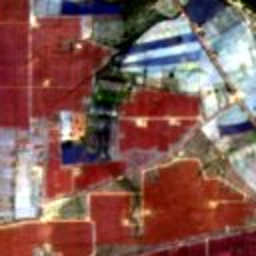

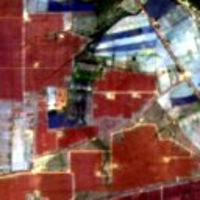

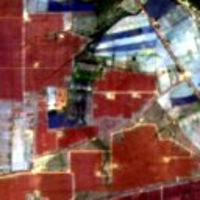

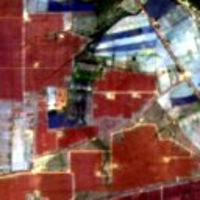

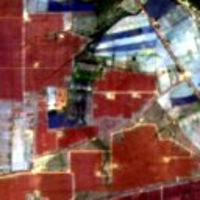

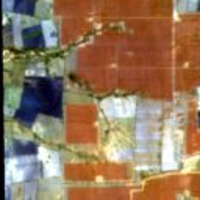

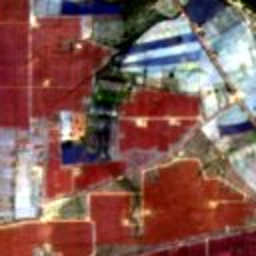

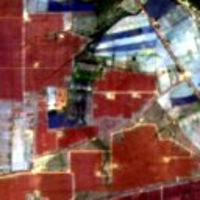

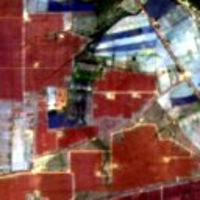

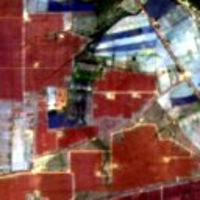

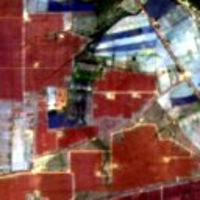

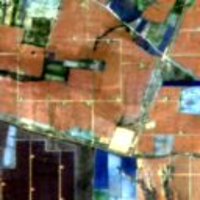

Done. If not enough neighbors were found from other parents, increase K_SEARCH and re-run with the same cell.


In [16]:
# Cell: retrieval_demo_no_same_parent - show query + neighbors from OTHER parent images (both RGB & MS)
import os, time, json
from pathlib import Path
import numpy as np, pandas as pd, faiss
from PIL import Image
from IPython.display import display, HTML
PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3 = PROJECT_ROOT / "stage3"
SHARDS = STAGE3 / "features_shards"
TILE_INDEX_PATH = STAGE3 / "tile_index_map.parquet"
IDX_RGB_PATH = STAGE3 / "faiss_hnsw_rgb.index"
IDX_MS_PATH  = STAGE3 / "faiss_hnsw_ms.index"

GLOBAL_ROW = 11945
K_RETURN = 5          # how many neighbors to show per branch (final)
K_SEARCH = 50         # how many neighbors to ask FAISS for, so filter can exclude same-parent

# helpers
def resolve_path(p):
    if p is None or (isinstance(p, float) and np.isnan(p)): return None
    s = str(p)
    s = s.replace("/gdrive/MyDrive","/content/drive/MyDrive").replace("/gdrive","/content/drive")
    if os.path.exists(s): return s
    # try relative under project
    alt = str(PROJECT_ROOT / p) if not s.startswith('/') else s
    if os.path.exists(alt): return alt
    return None

def load_vector(global_row, branch='rgb'):
    ti = pd.read_parquet(TILE_INDEX_PATH)
    r = ti.loc[ti['global_row']==global_row]
    if r.shape[0]==0:
        raise KeyError(f"global_row {global_row} not found")
    r = r.iloc[0]
    shard_id = r['shard_id']
    row_in_shard = int(r['row_in_shard'])
    fname = SHARDS / f"features_{shard_id}_{branch}.npy"
    if not fname.exists():
        raise FileNotFoundError(fname)
    arr = np.load(str(fname), mmap_mode='r')
    return arr[row_in_shard].astype('float32')

# load tile index and query meta
tile_index = pd.read_parquet(TILE_INDEX_PATH)
qmeta = tile_index.loc[tile_index['global_row']==GLOBAL_ROW]
if qmeta.shape[0]==0:
    raise KeyError(f"global_row {GLOBAL_ROW} not found in tile_index_map")
qmeta = qmeta.iloc[0]
query_parent = qmeta.get('parent_image') if 'parent_image' in qmeta.index else None
query_tile_id = qmeta['tile_id']
print(f"Query global_row={GLOBAL_ROW}, tile_id={query_tile_id}, parent={query_parent}")

# load indices and set efSearch
index_rgb = faiss.read_index(str(IDX_RGB_PATH))
index_ms  = faiss.read_index(str(IDX_MS_PATH))
try:
    index_rgb.hnsw.efSearch = 128
    index_ms.hnsw.efSearch = 128
except Exception:
    pass

# load query vectors
q_rgb = load_vector(GLOBAL_ROW, 'rgb').reshape(1,-1)
q_ms  = load_vector(GLOBAL_ROW, 'ms').reshape(1,-1)

# search K_SEARCH
t0 = time.time()
D_r, I_r = index_rgb.search(q_rgb.astype('float32'), K_SEARCH)
t1 = time.time()
D_m, I_m = index_ms.search(q_ms.astype('float32'), K_SEARCH)
t2 = time.time()
print(f"FAISS search times: RGB {t1-t0:.3f}s, MS {t2-t1:.3f}s. (asked K={K_SEARCH})")

# helper to convert id->meta
def ids_to_meta(ids, dists):
    rows=[]
    for idx,dist in zip(ids.tolist(), dists.tolist()):
        gr = int(idx)
        # guard: if gr not in tile_index (shouldn't happen) skip
        meta = tile_index.loc[tile_index['global_row']==gr]
        if meta.shape[0]==0:
            continue
        meta = meta.iloc[0]
        rows.append({
            'neighbor_global_row': gr,
            'neighbor_tile_id': meta['tile_id'],
            'parent_image': meta.get('parent_image', None),
            'shard_id': meta.get('shard_id', None),
            'row_in_shard': int(meta.get('row_in_shard')) if 'row_in_shard' in meta.index else None,
            'tile_path_tif': resolve_path(meta.get('tile_path_tif', None)),
            'tile_path_thumb': resolve_path(meta.get('tile_path_thumb', None)),
            'x_off': meta.get('x_off', None),
            'y_off': meta.get('y_off', None),
            'pct_nodata': meta.get('pct_nodata', None),
            'distance': float(dist)
        })
    return rows

rows_rgb_all = ids_to_meta(I_r[0], D_r[0])
rows_ms_all  = ids_to_meta(I_m[0], D_m[0])

# filter out same-parent (if query_parent is available)
def pick_other_parent(rows, K):
    out=[]
    for r in rows:
        if query_parent is None:
            # if no parent info, skip filter
            out.append(r)
        else:
            if r['parent_image'] != query_parent:
                out.append(r)
        if len(out) >= K:
            break
    return out

rows_rgb_other = pick_other_parent(rows_rgb_all, K_RETURN)
rows_ms_other  = pick_other_parent(rows_ms_all, K_RETURN)

print(f"Found {len(rows_rgb_other)} RGB neighbors from OTHER parents, {len(rows_ms_other)} MS neighbors from OTHER parents (requested {K_RETURN}).")

# Save results
out_df_rgb = pd.DataFrame(rows_rgb_other)
out_df_ms  = pd.DataFrame(rows_ms_other)
out_df_rgb['branch']='rgb'; out_df_ms['branch']='ms'
out_df = pd.concat([out_df_rgb, out_df_ms], ignore_index=True)
out_path = STAGE3 / f"output_retrieval_demo_{query_tile_id}_no_sameparent.parquet"
out_df.to_parquet(out_path, index=False)
print("Saved filtered retrieval results to:", out_path)

# Display query image then neighbor thumbnails (PIL display)
def show_img_grid(query_meta, rows, title):
    display(HTML(f"<h4>{title} (showing {len(rows)} neighbors)</h4>"))
    # show query first
    qthumb = resolve_path(query_meta.get('tile_path_thumb', None))
    if qthumb and os.path.exists(qthumb):
        display(HTML("<b>Query</b>"))
        display(Image.open(qthumb).resize((256,256)))
    else:
        display(HTML("<b>Query - thumbnail missing</b>"))
        # try tif
        tp = resolve_path(query_meta.get('tile_path_tif', None))
        if tp and os.path.exists(tp):
            display(Image.open(tp).resize((256,256)))
    # show neighbors
    for r in rows:
        p = r.get('tile_path_thumb') or r.get('tile_path_tif')
        cap = f"g:{r['neighbor_global_row']}<br>{r['neighbor_tile_id']}<br>dist:{r['distance']:.4f}<br>parent:{r['parent_image']}"
        if p and os.path.exists(p):
            display(HTML(f"<div style='display:inline-block;text-align:center;margin:6px'>{cap}</div>"))
            display(Image.open(p).resize((200,200)))
        else:
            display(HTML(f"<div style='display:inline-block;width:200px;height:200px;background:#eee;text-align:center;vertical-align:middle;margin:6px'>{cap}<br><small>No image</small></div>"))

# show RGB neighbors from other parents
show_img_grid(qmeta, rows_rgb_other, "RGB neighbors (other parents)")
# show MS neighbors from other parents
show_img_grid(qmeta, rows_ms_other, "MS neighbors (other parents)")

print("Done. If not enough neighbors were found from other parents, increase K_SEARCH and re-run with the same cell.")


Loaded tile_index_map rows: 12058
Columns before fix: ['global_row', 'tile_id', 'shard_id', 'row_in_shard', 'manifest_index', 'tile_path_tif', 'tile_path_thumb', 'x_off', 'y_off', 'tile_w', 'tile_h', 'pct_nodata', 'cloud_score']
Inferring parent_image for all rows...
Distinct parents inferred: 190
Backed up original to: /content/drive/MyDrive/project_visual_search/stage3/tile_index_map_parquet.bak.parquet
Wrote fixed tile_index_map to: /content/drive/MyDrive/project_visual_search/stage3/tile_index_map.parquet
Query global_row=11945, tile_id=GC01PS03D0155_x000384_y000384, parent=GC01PS03D0155
FAISS search times: RGB 0.001s, MS 0.001s (asked K=200)
Found 5 RGB neighbors from OTHER parents, 5 MS neighbors from OTHER parents (requested 5).
Saved filtered retrieval results to: /content/drive/MyDrive/project_visual_search/stage3/output_retrieval_demo_GC01PS03D0155_x000384_y000384_no_sameparent.parquet

Query image:


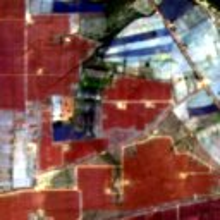


RGB neighbors (other parents):


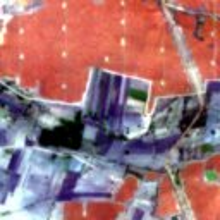

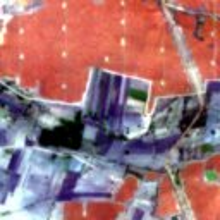

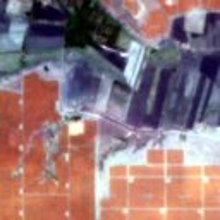

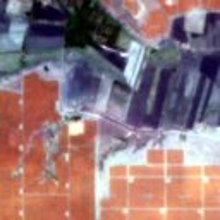

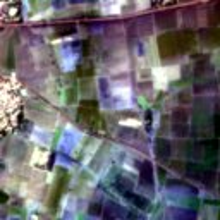


MS neighbors (other parents):


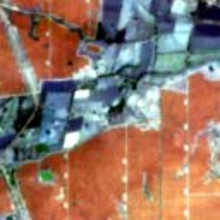

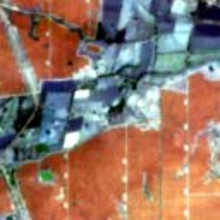

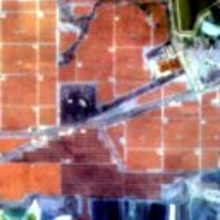

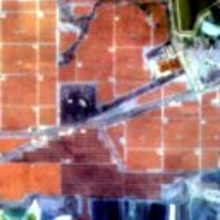

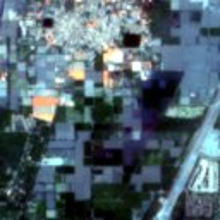


Done.


In [17]:
# Cell: Fix tile_index_map -> infer parent_image column, save backup, then rerun retrieval excluding same parent
import os, time
from pathlib import Path
import pandas as pd, numpy as np, faiss
from PIL import Image
from IPython.display import display, HTML

PROJECT_ROOT = Path("/content/drive/MyDrive/project_visual_search")
STAGE3 = PROJECT_ROOT / "stage3"
SHARDS = STAGE3 / "features_shards"
TILE_INDEX_PATH = STAGE3 / "tile_index_map.parquet"
BACKUP_PATH = STAGE3 / "tile_index_map_parquet.bak.parquet"
IDX_RGB_PATH = STAGE3 / "faiss_hnsw_rgb.index"
IDX_MS_PATH  = STAGE3 / "faiss_hnsw_ms.index"

GLOBAL_ROW = 11945
K_RETURN = 5
K_SEARCH = 200   # search more so filtering can find other-parent hits

# 1) load tile index
if not TILE_INDEX_PATH.exists():
    raise FileNotFoundError(f"{TILE_INDEX_PATH} not found")
ti = pd.read_parquet(TILE_INDEX_PATH)
print("Loaded tile_index_map rows:", len(ti))
print("Columns before fix:", list(ti.columns))

# 2) infer parent_image if missing or contains all-None
def infer_parent_from_path(p):
    try:
        s = str(p)
        parts = s.split('/')
        if 'tiles' in parts:
            i = parts.index('tiles')
            if i+1 < len(parts):
                return parts[i+1]
        # fallback: filename prefix before underscore
        fname = os.path.basename(s)
        return fname.split('_')[0]
    except:
        return None

need_fix = ('parent_image' not in ti.columns) or (ti['parent_image'].isna().all())
if need_fix:
    print("Inferring parent_image for all rows...")
    ti['parent_image'] = ti['tile_path_tif'].apply(infer_parent_from_path)
    # small sanity check: how many distinct parents?
    print("Distinct parents inferred:", ti['parent_image'].nunique())
else:
    print("parent_image column present; showing example values:")
    print(ti['parent_image'].dropna().unique()[:10])

# 3) backup current index file then overwrite with fixed version
ti.to_parquet(BACKUP_PATH, index=False)
ti.to_parquet(TILE_INDEX_PATH, index=False)
print(f"Backed up original to: {BACKUP_PATH}")
print(f"Wrote fixed tile_index_map to: {TILE_INDEX_PATH}")

# 4) re-run filtered retrieval (exclude same parent). Uses a larger K_SEARCH to ensure we can find outside-parent neighbors.
def resolve_path(p):
    if p is None or (isinstance(p, float) and np.isnan(p)): return None
    s = str(p).replace("/gdrive/MyDrive","/content/drive/MyDrive").replace("/gdrive","/content/drive")
    if os.path.exists(s): return s
    alt = str(PROJECT_ROOT / p) if not s.startswith('/') else s
    if os.path.exists(alt): return alt
    return None

def load_vector(global_row, branch='rgb'):
    meta = ti.loc[ti['global_row']==global_row]
    if meta.shape[0]==0:
        raise KeyError(f"global_row {global_row} not found")
    meta = meta.iloc[0]
    shard_id = meta['shard_id']
    row_in_shard = int(meta['row_in_shard'])
    fname = SHARDS / f"features_{shard_id}_{branch}.npy"
    if not fname.exists():
        raise FileNotFoundError(fname)
    arr = np.load(str(fname), mmap_mode='r')
    return arr[row_in_shard].astype('float32')

# load indices
if not IDX_RGB_PATH.exists() or not IDX_MS_PATH.exists():
    raise FileNotFoundError("FAISS index files missing in stage3/")
index_rgb = faiss.read_index(str(IDX_RGB_PATH))
index_ms  = faiss.read_index(str(IDX_MS_PATH))
try:
    index_rgb.hnsw.efSearch = 256
    index_ms.hnsw.efSearch = 256
except Exception:
    pass

# get query meta and vectors
qmeta = ti.loc[ti['global_row']==GLOBAL_ROW]
if qmeta.shape[0]==0:
    raise KeyError(f"query global_row {GLOBAL_ROW} not found")
qmeta = qmeta.iloc[0]
query_parent = qmeta.get('parent_image')
query_tile_id = qmeta['tile_id']
print(f"Query global_row={GLOBAL_ROW}, tile_id={query_tile_id}, parent={query_parent}")

q_rgb = load_vector(GLOBAL_ROW, 'rgb').reshape(1,-1)
q_ms  = load_vector(GLOBAL_ROW, 'ms').reshape(1,-1)

# search
t0 = time.time()
D_r, I_r = index_rgb.search(q_rgb, K_SEARCH)
t1 = time.time()
D_m, I_m = index_ms.search(q_ms, K_SEARCH)
t2 = time.time()
print(f"FAISS search times: RGB {t1-t0:.3f}s, MS {t2-t1:.3f}s (asked K={K_SEARCH})")

# ids -> meta rows (with resolved paths)
def ids_to_meta(ids, dists):
    rows=[]
    for idx, dist in zip(ids.tolist(), dists.tolist()):
        gr = int(idx)
        meta = ti.loc[ti['global_row']==gr]
        if meta.shape[0]==0:
            continue
        m = meta.iloc[0]
        rows.append({
            'neighbor_global_row': gr,
            'neighbor_tile_id': m['tile_id'],
            'parent_image': m.get('parent_image', None),
            'shard_id': m.get('shard_id', None),
            'row_in_shard': int(m.get('row_in_shard')) if 'row_in_shard' in m.index else None,
            'tile_path_tif': resolve_path(m.get('tile_path_tif', None)),
            'tile_path_thumb': resolve_path(m.get('tile_path_thumb', None)),
            'x_off': m.get('x_off', None),
            'y_off': m.get('y_off', None),
            'pct_nodata': m.get('pct_nodata', None),
            'distance': float(dist)
        })
    return rows

rows_rgb_all = ids_to_meta(I_r[0], D_r[0])
rows_ms_all  = ids_to_meta(I_m[0], D_m[0])

def pick_other_parent(rows, K):
    out=[]
    for r in rows:
        if query_parent is None:
            out.append(r)
        else:
            if r['parent_image'] != query_parent:
                out.append(r)
        if len(out) >= K:
            break
    return out

rows_rgb_other = pick_other_parent(rows_rgb_all, K_RETURN)
rows_ms_other  = pick_other_parent(rows_ms_all, K_RETURN)

print(f"Found {len(rows_rgb_other)} RGB neighbors from OTHER parents, {len(rows_ms_other)} MS neighbors from OTHER parents (requested {K_RETURN}).")

# save results
out_df = pd.DataFrame(rows_rgb_other + rows_ms_other)
out_path = STAGE3 / f"output_retrieval_demo_{query_tile_id}_no_sameparent.parquet"
out_df.to_parquet(out_path, index=False)
print("Saved filtered retrieval results to:", out_path)

# display query and neighbors (PIL) inline
def show_img(p, caption, size=(220,220)):
    if p and os.path.exists(p):
        try:
            im = Image.open(p).convert('RGB')
            display(HTML(f"<div style='display:inline-block;text-align:center;margin:6px'>{caption}</div>"))
            display(im.resize(size))
        except Exception as e:
            display(HTML(f"<div style='width:220px;height:220px;background:#eee;margin:6px;text-align:center;display:flex;align-items:center;justify-content:center;border:1px solid #ccc;'>{caption}<br><small>open error</small></div>"))
    else:
        display(HTML(f"<div style='width:220px;height:220px;background:#eee;margin:6px;text-align:center;display:flex;align-items:center;justify-content:center;border:1px solid #ccc;'>{caption}<br><small>missing</small></div>"))

print("\nQuery image:")
qthumb = resolve_path(qmeta.get('tile_path_thumb', None)) or resolve_path(qmeta.get('tile_path_tif', None))
show_img(qthumb, f"QUERY {query_tile_id} g:{GLOBAL_ROW}")

print("\nRGB neighbors (other parents):")
for r in rows_rgb_other:
    p = r.get('tile_path_thumb') or r.get('tile_path_tif')
    show_img(p, f"g:{r['neighbor_global_row']} {r['neighbor_tile_id']} dist:{r['distance']:.4f} parent:{r['parent_image']}")

print("\nMS neighbors (other parents):")
for r in rows_ms_other:
    p = r.get('tile_path_thumb') or r.get('tile_path_tif')
    show_img(p, f"g:{r['neighbor_global_row']} {r['neighbor_tile_id']} dist:{r['distance']:.4f} parent:{r['parent_image']}")

print("\nDone.")
